# PTT WomenTalk「難過」貼文：文辭分析、文件分類與主題模型

這份 notebook 以課堂第二次讀書會為目標，延續第一次讀書會的情緒分析基礎，進一步完成三大分析模組：

**Part 1 文辭分析**：TF-IDF 關鍵詞挑選、N-gram 統計、Bigram 網絡圖、Pairwise Correlation、Cosine Similarity。
**Part 2 文件分類**：監督式分類器（LR/RF/SVC/DT）、7:3 切分 + 5-fold CV、Confusion Matrix、迴歸係數分析、泛化測試。
**Part 3 主題模型**：gensim LDA、Perplexity / C_NPMI 掃 k、pyLDAvis 視覺化、GuidedLDA。

研究問題：
1. 各標籤（難過/閒聊/心情/討論）的用詞特徵有何差異？（Part 1）
2. 能否用文字特徵自動區分不同標籤的貼文？（Part 2）
3. 「難過」貼文中隱含哪些主要主題？（Part 3）

資料來源：PTT WomenTalk 板，以「難過」為關鍵字抓取，共 7,571 篇文章，時間跨度 2021–2025 年。

## 0. 環境、套件與執行提醒

建議在課堂的 `textmining` 環境中執行本 notebook：

```bash
conda activate textmining
pip install jieba scikit-learn networkx gensim pyLDAvis
```

補充說明：
- 本 notebook 的前處理（Step 1）只需執行一次，後續三個 Part 共用同一份斷詞結果與 TF-IDF 矩陣。
- 所有圖表以 notebook cell output 為主，不另外儲存圖片檔。
- 若某些套件缺少，相關段落會自動略過，不讓 notebook 中斷。

## 0.1 研究動機、資料來源與分析單位

在 PTT WomenTalk 板中，「難過」相關貼文常反映使用者在感情、人際、家庭、工作與自我情緒上的困擾。
本研究希望透過文辭分析、監督式分類與主題模型，從不同角度理解這類貼文的文字特徵與隱含結構。

本研究使用目前工作目錄中的 `sna2026s_11_3222ae0c1b_33.csv`，以 **article-level** 為主要分析單位。
主分析欄位包含：
- `artTitle`：文章標題（含標籤如 `[難過]`、`[閒聊]`）
- `artDate`：發文日期
- `artContent`：文章內文
- `artComment`：推文
- `artUrl`：文章網址

需要特別提醒的是，這份資料本身就是以「難過」作為關鍵字抓取，因此整體情緒偏負面是可預期的。

## 0.2 分析架構與報告閱讀路徑

整份報告依照「前處理 → 文辭 → 分類 → 主題」的順序安排：

1. **Step 1 前處理**：讀取資料、文字清理、jieba 斷詞、建立 TF-IDF 矩陣。這是地基，做一次後面全部共用。
2. **Part 1 文辭分析**：用 TF-IDF、N-gram、網絡圖、相關性與相似度，描述語料的詞彙特徵。
3. **Part 2 文件分類**：用標題標籤當 label，訓練監督式分類器，評估是否能自動區分不同類型貼文。
4. **Part 3 主題模型**：用 LDA 發現隱含主題，回答「大家到底在難過什麼」。

方法定位上，Part 1 回答「用了什麼詞」，Part 2 回答「能不能自動分類」，Part 3 回答「隱含哪些主題」。三者互相補強。

---
# Step 1. 前處理：讀取、清理、斷詞與 TF-IDF

這一段是所有後續分析的基礎，目的是把原始 CSV 轉換成可供分析的結構化資料。

本段會完成：
- 讀取 CSV，檢查資料大小、欄位與缺值。
- 抽取標題標籤（`[難過]`、`[閒聊]` 等）。
- 清理文字（去網址、簽名檔、非中文字元）。
- jieba 斷詞（搭配自訂詞典與停用字）。
- 建立 TF-IDF 矩陣。

In [1]:
# 1-1 套件匯入

import re, platform, importlib
import pandas as pd
import numpy as np
import jieba
import jieba.posseg as pseg
from collections import Counter
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import matplotlib

# 中文字型設定（依系統自動選擇）
if platform.system() == "Darwin":
    matplotlib.rcParams["font.family"] = ["Arial Unicode MS"]
elif platform.system() == "Windows":
    matplotlib.rcParams["font.family"] = ["Microsoft JhengHei"]
else:
    matplotlib.rcParams["font.family"] = ["Noto Sans CJK TC"]

matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# 檢查選用套件
optional = ["networkx", "seaborn", "gensim", "pyLDAvis"]
for pkg in optional:
    status = " " if importlib.util.find_spec(pkg) else "未安裝"
    print(f"  {pkg}: {status}")

print("\n必要套件載入完成")

  networkx:  
  seaborn:  
  gensim: 未安裝
  pyLDAvis: 未安裝

必要套件載入完成


In [2]:
# 1-2 設定工作目錄與輸出資料夾

base_dir = Path.cwd()
data_path = base_dir / "sna2026s_11_3222ae0c1b_33.csv"
results_dir = base_dir / "results"
results_dir.mkdir(parents=True, exist_ok=True)

print(f"目前工作目錄：{base_dir}")
print(f"資料檔案位置：{data_path}")
print(f"分析結果輸出：{results_dir}")

目前工作目錄：/Users/sylvia/Documents/Sylvia/社群媒體分析/第二次讀書會報告
資料檔案位置：/Users/sylvia/Documents/Sylvia/社群媒體分析/第二次讀書會報告/sna2026s_11_3222ae0c1b_33.csv
分析結果輸出：/Users/sylvia/Documents/Sylvia/社群媒體分析/第二次讀書會報告/results


## 1. 讀取資料與基本檢查

這一段的目的，是先回答最基本的研究設計問題：資料從哪裡來、期間多長、規模多大。

本段會完成：
- 讀取 CSV。
- 檢查資料大小、欄位、缺值、重複網址。
- 將 `artDate` 轉為 datetime，建立 `year`、`month_of_year` 等時間欄位。
- 說明資料期間與資料筆數。

In [3]:
# 1-3 讀取原始資料

if not data_path.exists():
    raise FileNotFoundError(f"找不到資料檔：{data_path}")

df_raw = pd.read_csv(data_path, encoding="utf-8-sig", low_memory=False)
print(f"成功讀取資料")
print(f"資料 shape：{df_raw.shape}")
print(f"欄位名稱：{df_raw.columns.tolist()}")
df_raw.head(3)

成功讀取資料
資料 shape：(7571, 11)
欄位名稱：['system_id', 'artUrl', 'artTitle', 'artDate', 'artPoster', 'artCatagory', 'artContent', 'artComment', 'e_ip', 'insertedDate', 'dataSource']


,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource
0,1,https://www.ptt.cc/bbs/WomenTalk/M.1609431742....,[難過]2020年12月步數不足,2021-01-01 00:22:20,johanzhou,WomenTalk,2020年12月實在是太太多事，沒辦法多走路，這幾個禮拜也都沒有跑步，於是步數就不足了。\n...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""rukawa514"", ...",42.74.30.7,2021-01-01 00:56:55,ptt
1,2,https://www.ptt.cc/bbs/WomenTalk/M.1609453123....,[難過]陽台又淹水了,2021-01-01 06:18:41,ffooxx,WomenTalk,大家...早安，我芙尼。\n\n大概五點的時候我被一陣電鈴聲吵醒，\n門一打開發現是樓下的鄰...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""molopo"", ""cm...",49.216.68.245,2021-01-02 00:46:24,ptt
2,3,https://www.ptt.cc/bbs/WomenTalk/M.1609473812....,[閒聊]關於朋友這件事：（,2021-01-01 12:03:30,winnie5286,WomenTalk,不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了。\n以為是真心的朋友，在我遇到很難過...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""g7a7n7"", ""cm...",27.242.222.34,2021-01-02 00:46:24,ptt


In [4]:
# 1-4 檢查缺值

missing_table = df_raw.isna().sum().reset_index()
missing_table.columns = ["column", "missing_count"]
missing_table["missing_ratio"] = (missing_table["missing_count"] / len(df_raw)).round(4)
print("表 1-4 缺值統計")
display(missing_table)

表 1-4 缺值統計


,column,missing_count,missing_ratio
0,system_id,0,0.0000
1,artUrl,0,0.0000
2,artTitle,0,0.0000
3,artDate,0,0.0000
4,artPoster,0,0.0000
5,artCatagory,0,0.0000
6,artContent,7,0.0009
7,artComment,0,0.0000
8,e_ip,48,0.0063
9,insertedDate,0,0.0000


In [5]:
# 1-5 檢查重複網址

duplicate_url_count = df_raw["artUrl"].duplicated().sum()
print(f"artUrl 重複筆數：{duplicate_url_count}")

# 建立主分析用的 df（去除 artContent 缺值的列）
df = df_raw.dropna(subset=["artContent"]).copy().reset_index(drop=True)
print(f"排除內文缺值後：{len(df)} 篇")

artUrl 重複筆數：0
排除內文缺值後：7564 篇


In [6]:
# 1-6 建立日期欄位與月份統計

df["artDate_dt"] = pd.to_datetime(df["artDate"], errors="coerce")
df["year"] = df["artDate_dt"].dt.year
df["month_of_year"] = df["artDate_dt"].dt.month

month_order = list(range(1, 13))
month_label_map = {m: f"{m}月" for m in month_order}

date_min = df["artDate_dt"].min()
date_max = df["artDate_dt"].max()
print(f"資料期間：{date_min.date()} ~ {date_max.date()}")
print(f"共跨 {df['year'].nunique()} 個年份：{sorted(df['year'].dropna().unique().astype(int))}")

monthly_counts = df.groupby("month_of_year").size().reindex(month_order, fill_value=0)
print(f"\n各月份文章數：")
for m, c in monthly_counts.items():
    print(f"  {m:2d}月：{c} 篇")

資料期間：2021-01-01 ~ 2025-12-20
共跨 5 個年份：[np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

各月份文章數：
   1月：761 篇
   2月：627 篇
   3月：597 篇
   4月：583 篇
   5月：652 篇
   6月：588 篇
   7月：600 篇
   8月：542 篇
   9月：638 篇
  10月：654 篇
  11月：687 篇
  12月：635 篇


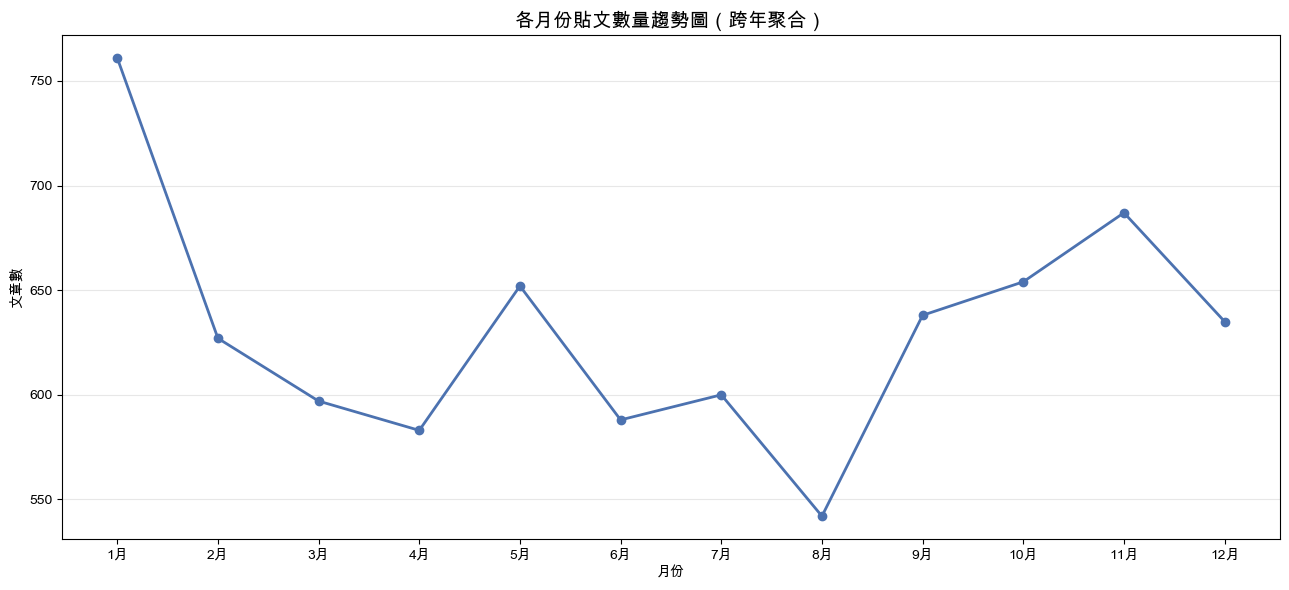

In [7]:
# 1-7 繪製各月份貼文數量趨勢圖

plt.figure(figsize=(13, 6))
plt.plot(monthly_counts.index, monthly_counts.values, marker="o", color="#4C72B0", linewidth=2)
plt.title("各月份貼文數量趨勢圖（跨年聚合）", fontsize=14)
plt.xlabel("月份")
plt.ylabel("文章數")
plt.xticks(month_order, [month_label_map[m] for m in month_order])
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 2. 文字清理與分析欄位建立

這一段對應課堂中的**前處理**，重點是把原始文字轉換成可供斷詞的乾淨文字。

主要處理：
- 抽取標題標籤（`[難過]`、`[閒聊]` 等），判斷是否為回文 `Re:` 或轉文 `Fw:`。
- 清理內文：移除網址、email、簽名檔、發信站資訊、非中文字元。
- 建立 `clean_content`（清理後內文）與 `analysis_text`（標題 + 內文合併）。
- 計算文章長度。

這樣做的好處是讓後面的斷詞不會被 URL、英文代碼等雜訊帶偏。

In [8]:
# 2-1 建立文字清理函式與分析欄位

def extract_tag(title):
    """抽取標題最前面的 [標籤]，容許 Re:/Fw: 前綴。"""
    if pd.isna(title):
        return "無標籤"
    title = str(title).strip()
    title = re.sub(r"^\s*(?:Re|Fw):\s*", "", title, flags=re.IGNORECASE)
    m = re.match(r"\[(.+?)\]", title)
    return m.group(1) if m else "無標籤"

def clean_title(title):
    """移除標籤與 Re:/Fw: 後的乾淨標題。"""
    if pd.isna(title):
        return ""
    title = str(title).strip()
    title = re.sub(r"^\s*(?:Re|Fw):\s*", "", title, flags=re.IGNORECASE)
    title = re.sub(r"^\[.+?\]\s*", "", title)
    return title.strip()

def clean_content(text):
    """清理 PTT 文章內文。"""
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[a-zA-Z0-9_]+@[a-zA-Z0-9_.]+", "", text)
    text = re.sub(r"--\n.*", "", text, flags=re.DOTALL)
    text = re.sub(r"※\s*發信站.*", "", text)
    text = re.sub(r"※\s*文章網址.*", "", text)
    text = re.sub(r"[^\u4e00-\u9fff\u3400-\u4dbf，。！？、；：「」（）\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 套用清理
df["tag"] = df["artTitle"].apply(extract_tag)
df["is_reply"] = df["artTitle"].str.contains(r"^\s*Re:", flags=re.IGNORECASE, na=False)
df["is_forward"] = df["artTitle"].str.contains(r"^\s*Fw:", flags=re.IGNORECASE, na=False)
df["clean_title"] = df["artTitle"].apply(clean_title)
df["clean_content"] = df["artContent"].apply(clean_content)
df["analysis_text"] = (df["clean_title"] + " " + df["clean_content"]).str.strip()
df["text_length"] = df["clean_content"].str.len()

print("文字清理完成")
print(f"平均內文長度：{df['text_length'].mean():.0f} 字")
print(f"中位數長度：{df['text_length'].median():.0f} 字")

文字清理完成
平均內文長度：238 字
中位數長度：117 字


In [9]:
# 2-2 顯示清理前後示例

examples = df.loc[
    df["clean_content"].str.len() > 50,
    ["artTitle", "clean_title", "artContent", "clean_content"]
].head(3).copy()
examples["artContent_preview"] = examples["artContent"].str[:150] + "..."
examples["clean_content_preview"] = examples["clean_content"].str[:150] + "..."

print("表 2-2 清理前後示例（前 3 篇）")
display(examples[["artTitle", "clean_title", "artContent_preview", "clean_content_preview"]])

表 2-2 清理前後示例（前 3 篇）


,artTitle,clean_title,artContent_preview,clean_content_preview
0,[難過]2020年12月步數不足,2020年12月步數不足,2020年12月實在是太太多事，沒辦法多走路，這幾個禮拜也都沒有跑步，於是步數就不足了。\n...,年 月實在是太太多事，沒辦法多走路，這幾個禮拜也都沒有跑步，於是步數就不足了。 平均一天也不...
1,[難過]陽台又淹水了,陽台又淹水了,大家...早安，我芙尼。\n\n大概五點的時候我被一陣電鈴聲吵醒，\n門一打開發現是樓下的鄰...,大家 早安，我芙尼。 大概五點的時候我被一陣電鈴聲吵醒， 門一打開發現是樓下的鄰居， 她問我...
2,[閒聊]關於朋友這件事：（,關於朋友這件事：（,不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了。\n以為是真心的朋友，在我遇到很難過...,不知道是不是年紀的關係 真的感覺身邊都沒有朋友了。 以為是真心的朋友，在我遇到很難過的事情想...


In [10]:
# 2-3 文章長度統計

print("表 2-3 文章長度基本統計（以 clean_content 字元數計算）")
display(df["text_length"].describe().round(1).to_frame("text_length"))

表 2-3 文章長度基本統計（以 clean_content 字元數計算）


,text_length
count,7564.0
mean,237.6
std,453.2
min,0.0
25%,78.0
50%,117.0
75%,231.0
max,21645.0


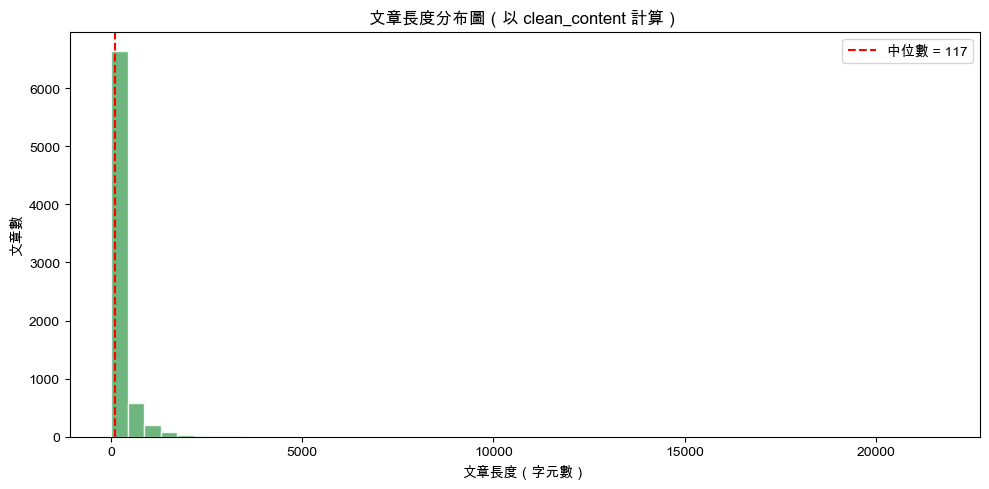

In [11]:
# 2-4 繪製文章長度分布圖

plt.figure(figsize=(10, 5))
plt.hist(df["text_length"], bins=50, color="#55A868", edgecolor="white", alpha=0.85)
plt.axvline(df["text_length"].median(), color="red", linestyle="--",
            label=f"中位數 = {df['text_length'].median():.0f}")
plt.xlabel("文章長度（字元數）")
plt.ylabel("文章數")
plt.title("文章長度分布圖（以 clean_content 計算）")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# 2-5 標題標籤分布與回文比例

tag_counts = df["tag"].value_counts().reset_index()
tag_counts.columns = ["tag", "count"]
tag_counts["ratio"] = (tag_counts["count"] / len(df)).round(4)

print("表 2-5 標題標籤分布")
display(tag_counts)

reply_ratio = df["is_reply"].mean()
print(f"\n回文（Re:）比例：{reply_ratio:.2%}（{df['is_reply'].sum()} 篇）")
print(f"轉文（Fw:）比例：{df['is_forward'].mean():.2%}（{df['is_forward'].sum()} 篇）")

表 2-5 標題標籤分布


,tag,count,ratio
0,難過,6218,0.8221
1,閒聊,495,0.0654
2,心情,366,0.0484
3,討論,164,0.0217
4,問題,153,0.0202
5,新聞,123,0.0163
6,無標籤,19,0.0025
7,灑花,14,0.0019
8,活動,4,0.0005
9,問卦,3,0.0004



回文（Re:）比例：21.51%（1627 篇）
轉文（Fw:）比例：0.22%（17 篇）


In [ ]:
# 2-6 繪製標題標籤分布圖

top_tags = tag_counts.head(10)
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_tags)-1, -1, -1), top_tags["count"], color="#937860")
plt.yticks(range(len(top_tags)-1, -1, -1), top_tags["tag"])
plt.xlabel("文章數")
plt.title("標題標籤分布 Top 10")
plt.tight_layout()
plt.show()

## 3. 斷詞、自訂詞典與停用字

這一段是文字探勘的核心前處理。
為了讓 jieba 正確辨識 PTT 與情感領域的用詞，這裡會載入自訂詞典並設定停用字。

處理流程：
1. 載入自訂詞典（感情、職場、家庭、情緒相關用詞）。
2. 設定停用字（功能詞 + PTT 常見雜訊詞 + 「難過」本身）。
3. 對每篇文章執行 jieba 斷詞。
4. 建立 `tokens`（詞列表）與 `tokens_str`（空格分隔字串，給 TF-IDF 用）。

「難過」被列入停用字是因為它是搜尋關鍵字，幾乎每篇都有，留著會淹沒其他有意義的詞。

In [13]:
# 3-1 載入自訂詞典

custom_words = sorted({
    # 感情：分手與失戀
    "分手", "失戀", "前任", "復合", "被甩", "被分手", "失戀中",
    # 感情：曖昧與追求
    "曖昧", "告白", "被拒", "拒絕", "暈船", "單戀", "追求",
    # 感情：伴侶稱謂
    "男友", "女友", "伴侶", "另一半", "老公", "老婆", "先生", "太太",
    "前男友", "前女友",
    # 感情：衝突
    "吵架", "冷戰", "冷暴力", "已讀不回", "沒安全感",
    # 感情：外遇
    "外遇", "劈腿", "出軌", "偷吃", "小三",
    # 職場
    "主管", "上司", "老闆", "職場霸凌", "被罵", "慣老闆",
    "同事", "職場", "離職", "轉職", "面試", "求職",
    # 家庭
    "婆婆", "婆媳", "公婆", "懷孕", "流產", "不孕",
    # 情緒
    "憂鬱", "焦慮", "恐慌", "失眠", "自卑", "崩潰",
})

for w in custom_words:
    jieba.add_word(w)

print(f"自訂詞典載入完成，共 {len(custom_words)} 個詞")

Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/nv/y10bynyn1rs6_k94rcfl49rm0000gn/T/jieba.cache
Loading model cost 0.579 seconds.
Prefix dict has been built successfully.


自訂詞典載入完成，共 58 個詞


In [14]:
# 3-2 設定停用字

stopwords = {
    # 功能詞
    "的", "了", "和", "是", "我", "你", "他", "她", "它", "我們", "你們", "他們",
    "自己", "真的", "就是", "這樣", "那樣", "一個", "一些", "一下", "不是", "因為",
    "所以", "如果", "然後", "但是", "而且", "可以", "還是", "沒有", "有點", "知道",
    "覺得", "可能", "應該", "已經", "非常", "最近", "今天", "昨天", "現在", "時候",
    "東西", "事情", "問題", "什麼", "怎麼", "這個", "那個", "一樣", "一點", "很多",
    "一直", "還有", "只是", "不過", "其實", "那時", "後來", "之前", "之後",
    "雖然", "不會", "大家", "有人", "也是", "這種", "那種", "比較", "感覺", "到底",
    "為什麼", "開始", "希望", "想說", "出來", "告訴", "看到", "過去",
    # 搜尋關鍵字（幾乎每篇都有，排除以免干擾）
    "難過",
    # PTT 雜訊
    "ptt", "womentalk", "發信站", "批踢踢", "文章", "板友",
}

print(f"停用詞設定完成，共 {len(stopwords)} 個")

停用詞設定完成，共 86 個


In [15]:
# 3-3 執行斷詞

def tokenize(text):
    """jieba 斷詞 → 過濾停用字 & 單字。"""
    if not text:
        return []
    words = jieba.cut(text)
    return [w for w in words if w not in stopwords and len(w) >= 2]

print("開始斷詞（約需 1-3 分鐘）...")
df["tokens"] = df["analysis_text"].apply(tokenize)
df["tokens_str"] = df["tokens"].apply(lambda t: " ".join(t))

print(f"斷詞完成")
print(f"平均每篇：{df['tokens'].apply(len).mean():.0f} 個詞")
print(f"\n前 3 篇斷詞預覽：")
for i in range(3):
    print(f"  [{df.iloc[i]['tag']}] {df.iloc[i]['tokens'][:12]}...")

開始斷詞（約需 1-3 分鐘）...
斷詞完成
平均每篇：62 個詞

前 3 篇斷詞預覽：
  [難過] ['2020', '12', '步數', '不足', '月實', '太太', '多事', '沒辦', '法多', '走路', '這幾個', '禮拜']...
  [難過] ['陽台', '淹水', '早安', '芙尼', '大概', '五點', '一陣', '電鈴聲', '吵醒', '一打', '開發現', '鄰居']...
  [閒聊] ['關於', '朋友', '這件', '是不是', '年紀的關', '身邊', '朋友', '以為', '真心', '朋友', '遇到', '想訴']...


In [16]:
# 3-4 全語料高頻詞 Top 30（確認斷詞品質）

all_tokens = [w for tokens in df["tokens"] for w in tokens]
freq = Counter(all_tokens)
top30_freq = pd.DataFrame(freq.most_common(30), columns=["word", "count"])

print("表 3-4 全語料高頻詞 Top 30（確認斷詞品質）")
display(top30_freq)

print("\n解讀：若出現過多無意義的功能詞，應回頭補進停用字。")

表 3-4 全語料高頻詞 Top 30（確認斷詞品質）


,word,count
0,朋友,1797
1,工作,1795
2,不要,1604
3,結果,1485
4,台灣,1214
5,是不是,1205
6,發現,1167
7,時間,1086
8,小孩,1030
9,這麼,997



解讀：若出現過多無意義的功能詞，應回頭補進停用字。


## 4. 建立 TF-IDF 矩陣

TF-IDF（Term Frequency–Inverse Document Frequency）是後續所有 Part 的共用基礎：
- Part 1 用它做關鍵詞挑選與 Cosine Similarity。
- Part 2 用它當分類器的特徵矩陣。
- Part 3 的 LDA 雖然用 BoW，但 TF-IDF 可做比較基線。

這裡會過濾太短的文章（< 30 字），並限制特徵詞範圍（min_df=5, max_df=0.8, max_features=5000），避免過於稀疏的詞干擾分析。

In [17]:
# 4-1 建立 TF-IDF 矩陣

# 過濾太短的文章
df_analysis = df[df["text_length"] >= 30].copy().reset_index(drop=True)
print(f"分析樣本：{len(df_analysis)} 篇（排除 < 30 字的文章，原始 {len(df)} 篇）")

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
)
tfidf_matrix = tfidf_vectorizer.fit_transform(df_analysis["tokens_str"])
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF 矩陣建立完成：{tfidf_matrix.shape}")
print(f"   {tfidf_matrix.shape[0]} 篇文章 × {tfidf_matrix.shape[1]} 個特徵詞")

分析樣本：7541 篇（排除 < 30 字的文章，原始 7564 篇）
TF-IDF 矩陣建立完成：(7541, 5000)
   7541 篇文章 × 5000 個特徵詞


In [18]:
# 4-2 輸出前處理完成的資料

output_cols = [
    "artTitle", "tag", "is_reply", "is_forward", "clean_title",
    "artDate", "artContent", "clean_content", "analysis_text",
    "text_length", "year", "month_of_year", "artUrl",
]
df_analysis[output_cols].to_csv(
    results_dir / "cleaned_articles.csv", index=False, encoding="utf-8-sig"
)
print(f"已輸出清理後資料：{results_dir / 'cleaned_articles.csv'}")
print(f"\nStep 1 前處理全部完成，以下進入 Part 1 文辭分析。")

已輸出清理後資料：/Users/sylvia/Documents/Sylvia/社群媒體分析/第二次讀書會報告/results/cleaned_articles.csv

Step 1 前處理全部完成，以下進入 Part 1 文辭分析。


---
# Part 1. 文辭分析

這一段使用多種文字統計方法，從不同角度描述語料的詞彙特徵：

| 方法 | 回答什麼問題 |
|------|-------------|
| TF-IDF 關鍵詞 | 哪些詞在區分文章時最重要？ |
| N-gram 統計 | 哪些詞經常連在一起出現？ |
| Bigram 網絡圖 | 詞與詞之間的共現關係長什麼樣？ |
| Pairwise Correlation | 哪些詞傾向一起出現？哪些互斥？ |
| Cosine Similarity | 不同標籤的文章用詞有多相似？ |

## Part 1-1. TF-IDF 關鍵詞挑選

TF-IDF 的核心想法是：一個詞如果在某篇文章中頻繁出現，但在整體語料中並不常見，那它對該篇文章就特別重要。

這裡會從兩個角度呈現：
1. **全語料** TF-IDF 平均分數最高的詞 — 描述整體語料的關鍵詞輪廓。
2. **各標籤** 的 TF-IDF 關鍵詞 — 比較「難過」、「閒聊」、「心情」、「討論」四類文章的用詞差異。

In [19]:
# P1-1a 全語料 TF-IDF 平均分數 Top 30

mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()
top_tfidf_idx = mean_tfidf.argsort()[::-1][:30]

tfidf_top30 = pd.DataFrame({
    "word": tfidf_feature_names[top_tfidf_idx],
    "mean_tfidf": mean_tfidf[top_tfidf_idx].round(4),
})

print("表 P1-1a 全語料 TF-IDF 平均分數 Top 30")
display(tfidf_top30)

表 P1-1a 全語料 TF-IDF 平均分數 Top 30


,word,mean_tfidf
0,工作,0.0150
1,朋友,0.0148
2,結果,0.0147
3,是不是,0.0143
4,同事,0.0129
5,發現,0.0118
6,不要,0.0117
7,台灣,0.0115
8,上班,0.0109
9,喜歡,0.0107


In [21]:
# P1-1b 各標籤的 TF-IDF 關鍵詞 Top 10

print("各標籤 TF-IDF 關鍵詞 Top 10：\n")
for tag_name in ["難過", "閒聊", "心情", "討論"]:
    tag_mask = (df_analysis["tag"] == tag_name).values
    if tag_mask.sum() < 10:
        continue
    tag_mean = np.array(tfidf_matrix[tag_mask].mean(axis=0)).flatten()
    top_idx = tag_mean.argsort()[::-1][:10]
    keywords = ", ".join(tfidf_feature_names[top_idx])
    print(f"  [{tag_name}]（{tag_mask.sum()} 篇）：{keywords}")

各標籤 TF-IDF 關鍵詞 Top 10：

  [難過]（6198 篇）：結果, 是不是, 工作, 同事, 朋友, 上班, 發現, 台灣, 如題, 這麼
  [閒聊]（495 篇）：朋友, 喜歡, 好像, 台灣, 工作, 小孩, 不要, 想到, 結果, 人生
  [心情]（365 篇）：朋友, 情緒, 工作, 一起, 心情, 不要, 喜歡, 媽媽, 男友, 家人
  [討論]（163 篇）：朋友, 不要, 女生, 是不是, 喜歡, 一起, 開心, 這些, 不能, 好像


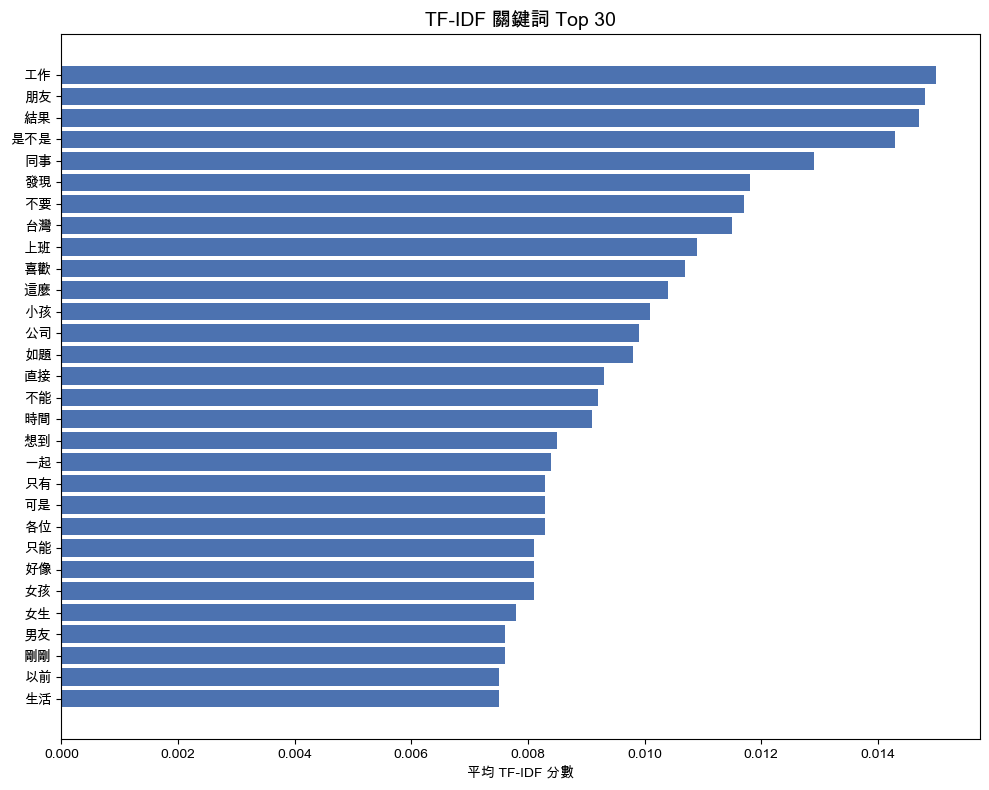

解讀：TF-IDF 分數高的詞代表在區分文章時最具辨識力的詞彙。


In [22]:
# P1-1c 視覺化：TF-IDF Top 30 長條圖

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(tfidf_top30)-1, -1, -1), tfidf_top30["mean_tfidf"], color="#4C72B0")
ax.set_yticks(range(len(tfidf_top30)-1, -1, -1))
ax.set_yticklabels(tfidf_top30["word"])
ax.set_xlabel("平均 TF-IDF 分數")
ax.set_title("TF-IDF 關鍵詞 Top 30", fontsize=14)
plt.tight_layout()
plt.show()

print("解讀：TF-IDF 分數高的詞代表在區分文章時最具辨識力的詞彙。")

## Part 1-2. N-gram 統計

N-gram 統計的目的是找出經常連續出現的詞組合：
- **Bigram（2-gram）**：兩個詞的組合，例如「分手 男友」。
- **Trigram（3-gram）**：三個詞的組合，例如「分手 男友 難過」。

這比單詞頻率多了「詞序」的資訊，能幫助辨識具體事件或固定搭配。

In [23]:
# P1-2a Bigram & Trigram 統計

# Bigram
bigram_vec = CountVectorizer(ngram_range=(2, 2), max_features=3000, min_df=3)
bigram_mat = bigram_vec.fit_transform(df_analysis["tokens_str"])
bigram_freq = np.array(bigram_mat.sum(axis=0)).flatten()
bigram_names = bigram_vec.get_feature_names_out()
bigram_top30 = pd.DataFrame({
    "bigram": bigram_names[bigram_freq.argsort()[::-1][:30]],
    "count": sorted(bigram_freq, reverse=True)[:30],
})

# Trigram
trigram_vec = CountVectorizer(ngram_range=(3, 3), max_features=3000, min_df=3)
trigram_mat = trigram_vec.fit_transform(df_analysis["tokens_str"])
trigram_freq = np.array(trigram_mat.sum(axis=0)).flatten()
trigram_names = trigram_vec.get_feature_names_out()
trigram_top20 = pd.DataFrame({
    "trigram": trigram_names[trigram_freq.argsort()[::-1][:20]],
    "count": sorted(trigram_freq, reverse=True)[:20],
})

print("表 P1-2a Bigram Top 30")
display(bigram_top30)
print("\n表 P1-2b Trigram Top 20")
display(trigram_top20)

表 P1-2a Bigram Top 30


,bigram,count
0,啊啊啊 啊啊啊,320
1,詐騙 集團,72
2,一段 時間,72
3,情緒 勒索,69
4,原生 家庭,62
5,新聞 標題,60
6,三十 無力,58
7,新聞 連結,55
8,不想 上班,50
9,大學 畢業,50



表 P1-2b Trigram Top 20


,trigram,count
0,啊啊啊 啊啊啊 啊啊啊,301
1,新聞 連結 心得,48
2,上班 不想 上班,26
3,不想 上班 不想,26
4,近視 雷射 手術,23
5,男友 結婚 不想,23
6,好友 人生 過的,22
7,差不多 好友 人生,22
8,程度 差不多 好友,22
9,各位 女板 姊姊,19


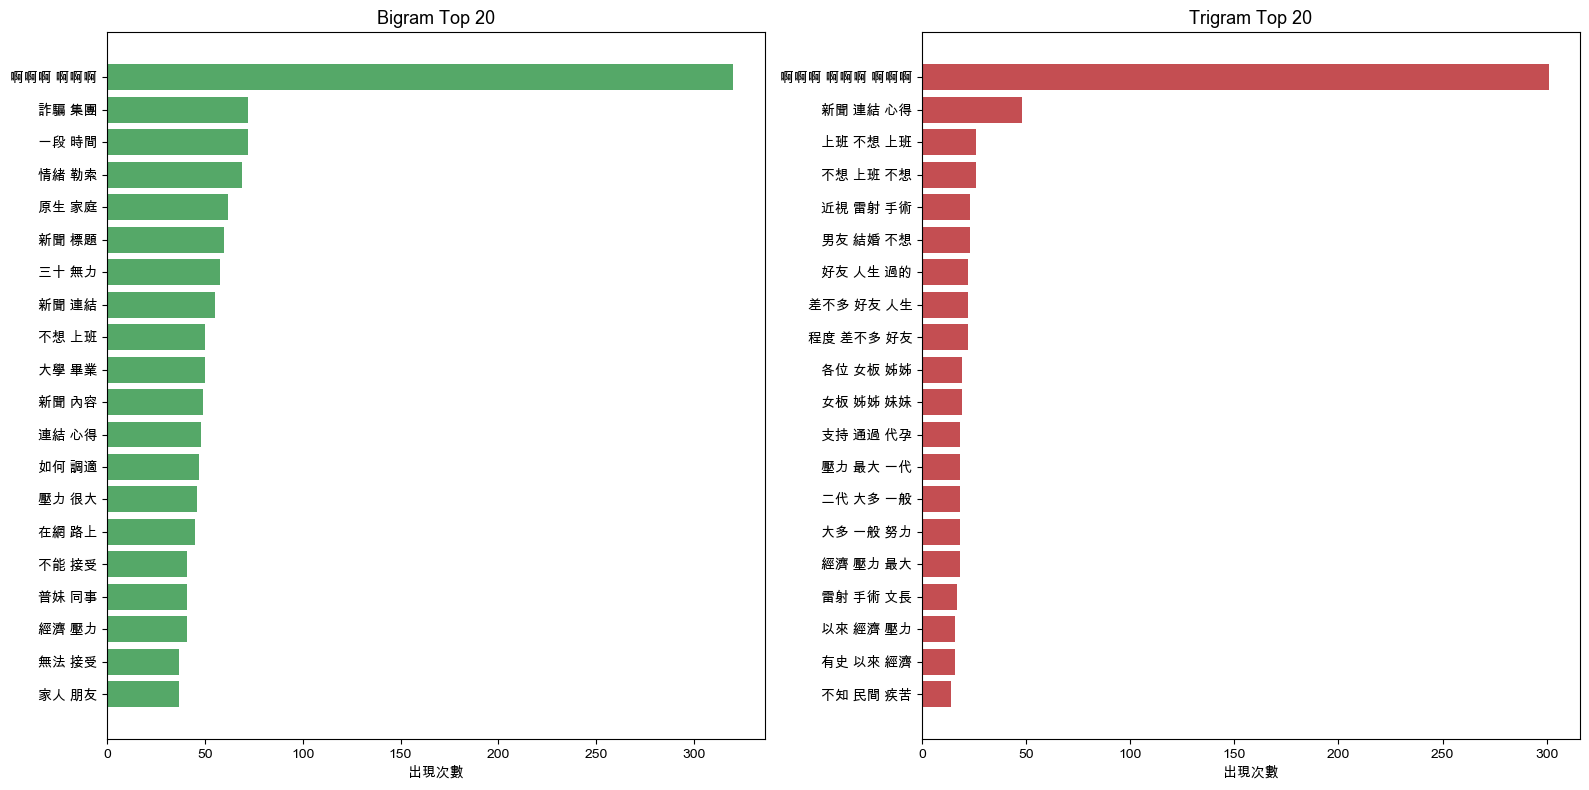

解讀：Bigram 與 Trigram 能揭示具體事件搭配，例如「分手+男友」、「工作+壓力+離職」等。


In [24]:
# P1-2b 視覺化：Bigram & Trigram 並排長條圖

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(range(19, -1, -1), bigram_top30["count"].head(20), color="#55A868")
axes[0].set_yticks(range(19, -1, -1))
axes[0].set_yticklabels(bigram_top30["bigram"].head(20))
axes[0].set_xlabel("出現次數")
axes[0].set_title("Bigram Top 20", fontsize=13)

axes[1].barh(range(19, -1, -1), trigram_top20["count"], color="#C44E52")
axes[1].set_yticks(range(19, -1, -1))
axes[1].set_yticklabels(trigram_top20["trigram"])
axes[1].set_xlabel("出現次數")
axes[1].set_title("Trigram Top 20", fontsize=13)

plt.tight_layout()
plt.show()

print("解讀：Bigram 與 Trigram 能揭示具體事件搭配，例如「分手+男友」、「工作+壓力+離職」等。")

## Part 1-3. Bigram 網絡圖

Bigram 網絡圖把高頻共現的詞對視覺化成一張圖：
- **節點** = 詞，大小代表出現頻率。
- **邊** = 兩個詞相鄰出現，粗細代表共現次數。

這張圖能一眼看出語料中的「詞群」——哪些詞形成緊密的聚落，哪些詞是連接不同話題的橋樑。

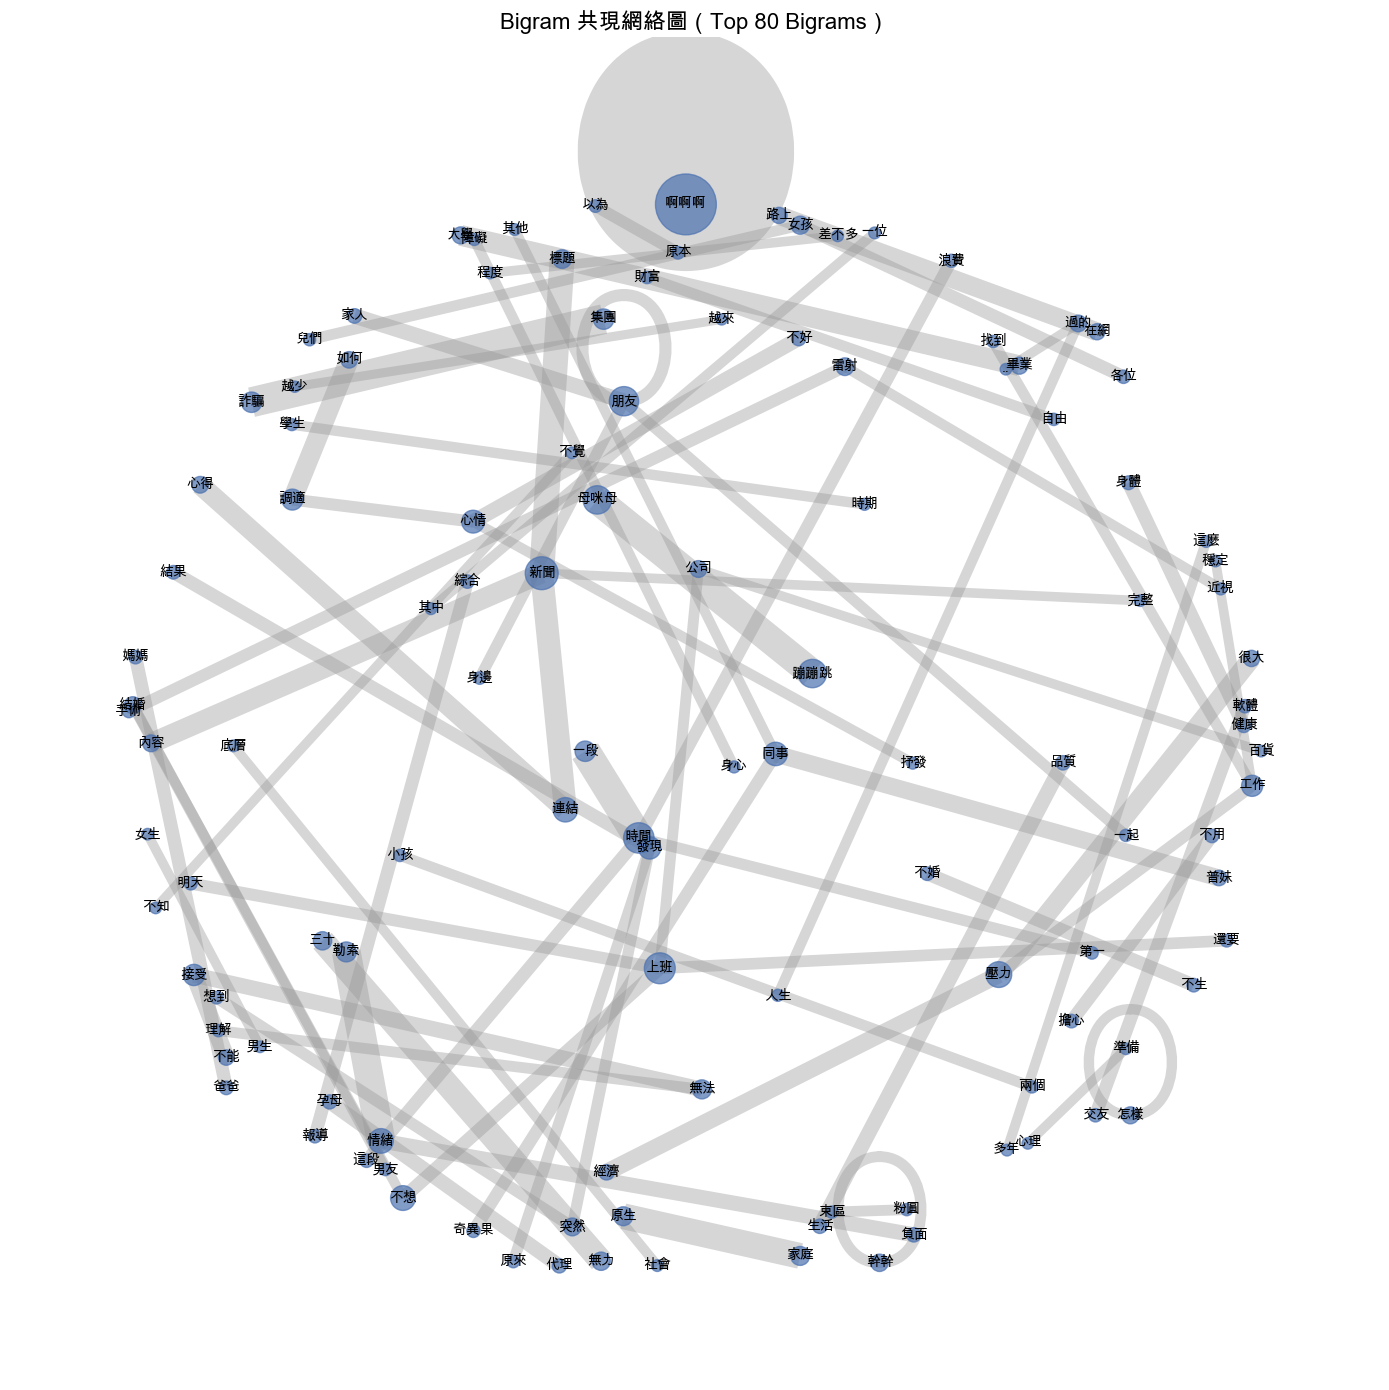

節點數：118
邊數：78

解讀：聚落代表相關話題群，橋樑節點是跨話題的關鍵詞。


In [25]:
# P1-3 Bigram 共現網絡圖

import networkx as nx

bigram_counter = Counter()
for tokens in df_analysis["tokens"]:
    for i in range(len(tokens) - 1):
        bigram_counter[(tokens[i], tokens[i+1])] += 1

# 取 Top 80 的 bigram（太多會很亂）
top_bigrams = bigram_counter.most_common(80)

G = nx.Graph()
for (w1, w2), count in top_bigrams:
    G.add_edge(w1, w2, weight=count)

# 節點大小 = 出現頻率，邊粗細 = 共現次數
node_freq = Counter()
for (w1, w2), count in top_bigrams:
    node_freq[w1] += count
    node_freq[w2] += count

node_sizes = [node_freq.get(n, 1) * 3 for n in G.nodes()]
edge_weights = [G[u][v]["weight"] * 0.3 for u, v in G.edges()]

plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, k=2.5, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="#4C72B0", alpha=0.7)
nx.draw_networkx_edges(G, pos, width=edge_weights, alpha=0.4, edge_color="#999999")

# 字型：請根據你的系統調整
font_name = "Arial Unicode MS"  # macOS；Windows 改 "Microsoft JhengHei"
nx.draw_networkx_labels(G, pos, font_size=10, font_family=font_name)

plt.title("Bigram 共現網絡圖（Top 80 Bigrams）", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"節點數：{G.number_of_nodes()}")
print(f"邊數：{G.number_of_edges()}")
print("\n解讀：聚落代表相關話題群，橋樑節點是跨話題的關鍵詞。")

## Part 1-4. Pairwise Correlation（詞彙共現相關性）

Pairwise Correlation 用 **Phi 係數**（等同於 binary 資料上的 Pearson 相關）衡量兩個詞是否傾向一起出現：
- **正相關**：兩個詞經常同時出現在同一篇文章中（例如「分手」與「前任」）。
- **負相關**：兩個詞很少同時出現（例如「工作」與「懷孕」——通常是不同話題）。

這跟 N-gram 不同：N-gram 看的是**相鄰**出現，Correlation 看的是**同篇文章內**共現，不要求詞緊鄰。

In [26]:
# P1-4a 計算 Pairwise Phi Correlation

binary_vec = CountVectorizer(binary=True, min_df=50, max_df=0.8, max_features=200)
binary_mat = binary_vec.fit_transform(df_analysis["tokens_str"])
binary_names = binary_vec.get_feature_names_out()

binary_dense = binary_mat.toarray()
corr_matrix = np.corrcoef(binary_dense.T)

# 取出所有詞對的相關係數
n_words = len(binary_names)
corr_pairs = []
for i in range(n_words):
    for j in range(i+1, n_words):
        corr_pairs.append((binary_names[i], binary_names[j], corr_matrix[i, j]))
corr_pairs.sort(key=lambda x: x[2], reverse=True)

print("表 P1-4a 最高正相關詞對 Top 20（傾向一起出現）")
corr_top20 = pd.DataFrame(corr_pairs[:20], columns=["word_1", "word_2", "phi_corr"])
corr_top20["phi_corr"] = corr_top20["phi_corr"].round(4)
display(corr_top20)

print("\n表 P1-4b 最高負相關詞對 Top 10（傾向互斥）")
corr_bottom10 = pd.DataFrame(corr_pairs[-10:], columns=["word_1", "word_2", "phi_corr"])
corr_bottom10["phi_corr"] = corr_bottom10["phi_corr"].round(4)
display(corr_bottom10)

表 P1-4a 最高正相關詞對 Top 20（傾向一起出現）


,word_1,word_2,phi_corr
0,女生,男生,0.4043
1,媽媽,爸爸,0.3441
2,朋友,認識,0.2539
3,主管,公司,0.2349
4,小孩,父母,0.2336
5,工作,薪水,0.2183
6,分享,經驗,0.2005
7,家庭,父母,0.1987
8,主管,同事,0.1980
9,公司,工作,0.1971



表 P1-4b 最高負相關詞對 Top 10（傾向互斥）


,word_1,word_2,phi_corr
0,同事,新聞,-0.0425
1,不能,如題,-0.0440
2,各位,是不是,-0.0445
3,如題,選擇,-0.0447
4,台灣,同事,-0.0447
5,台灣,早上,-0.0465
6,如題,小孩,-0.0491
7,各位,如題,-0.0497
8,不要,如題,-0.0507
9,一定,如題,-0.0532


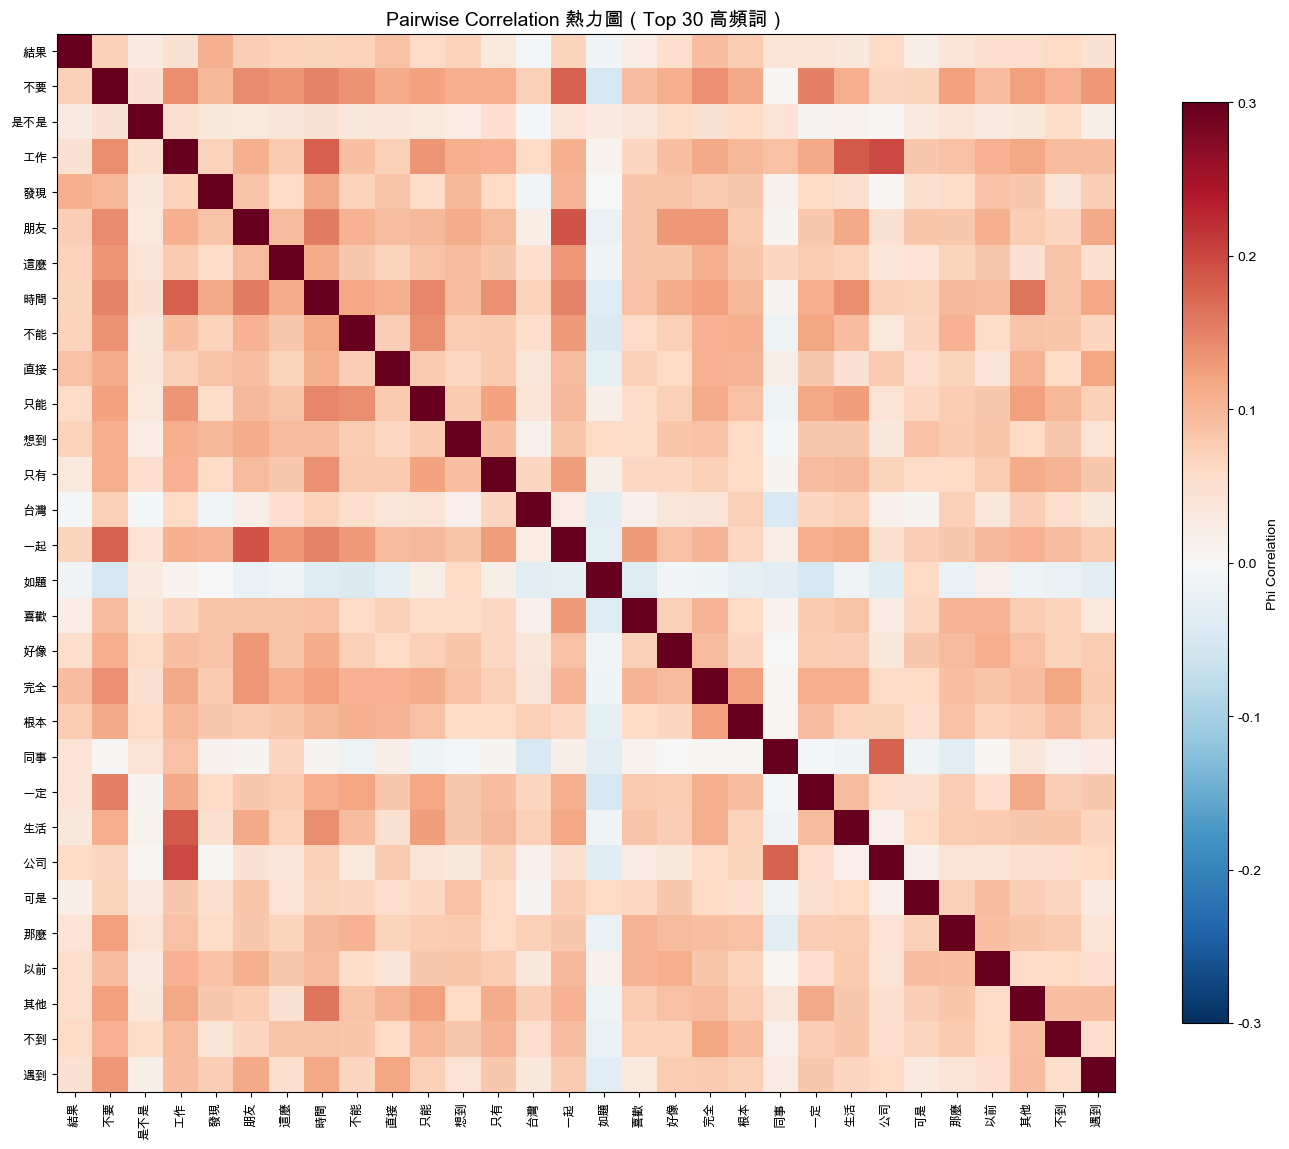

解讀：紅色 = 正相關（常共現），藍色 = 負相關（互斥），白色 = 無明顯關聯。


In [27]:
# P1-4b 視覺化：Pairwise Correlation 熱力圖（Top 30 高頻詞）

word_freq_in_binary = binary_dense.sum(axis=0)
top30_idx = word_freq_in_binary.argsort()[::-1][:30]
top30_words = binary_names[top30_idx]
sub_corr = corr_matrix[np.ix_(top30_idx, top30_idx)]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(sub_corr, cmap="RdBu_r", vmin=-0.3, vmax=0.3)
ax.set_xticks(range(30))
ax.set_yticks(range(30))
ax.set_xticklabels(top30_words, rotation=90, fontsize=9)
ax.set_yticklabels(top30_words, fontsize=9)
ax.set_title("Pairwise Correlation 熱力圖（Top 30 高頻詞）", fontsize=14)
plt.colorbar(im, ax=ax, shrink=0.8, label="Phi Correlation")
plt.tight_layout()
plt.show()

print("解讀：紅色 = 正相關（常共現），藍色 = 負相關（互斥），白色 = 無明顯關聯。")

## Part 1-5. Cosine Similarity（文件相似度）

Cosine Similarity 衡量兩篇文章（或兩組文章）在 TF-IDF 空間中的方向相似程度：
- 值越接近 1，代表用詞越相似。
- 值越接近 0，代表用詞差異越大。

這裡從兩個層次分析：
1. **標籤層級**：計算「難過」、「閒聊」、「心情」、「討論」四類文章 TF-IDF 中心點之間的 Cosine Similarity，看不同標籤的文章在用詞上有多相似。
2. **文件層級**：隨機抽 500 篇，計算所有兩兩配對的 Cosine Similarity 分布，了解整體語料的同質性。

In [28]:
# P1-5a 各標籤 TF-IDF 中心點的 Cosine Similarity

tag_groups = ["難過", "閒聊", "心情", "討論"]
tag_centroids = []
for tag_name in tag_groups:
    mask = (df_analysis["tag"] == tag_name).values
    if mask.sum() > 0:
        centroid = np.array(tfidf_matrix[mask].mean(axis=0)).flatten()
        tag_centroids.append(centroid)

tag_cos_sim = cosine_similarity(tag_centroids)
tag_cos_df = pd.DataFrame(tag_cos_sim, index=tag_groups, columns=tag_groups).round(4)

print("表 P1-5a 各標籤 TF-IDF 中心點 Cosine Similarity")
display(tag_cos_df)

表 P1-5a 各標籤 TF-IDF 中心點 Cosine Similarity


,難過,閒聊,心情,討論
難過,1.0000,0.8552,0.8224,0.7621
閒聊,0.8552,1.0000,0.8565,0.8051
心情,0.8224,0.8565,1.0000,0.7919
討論,0.7621,0.8051,0.7919,1.0000


In [29]:
# P1-5b 文件間 Cosine Similarity 分布

np.random.seed(42)
sample_size = min(500, len(df_analysis))
sample_idx = np.random.choice(len(df_analysis), sample_size, replace=False)
sample_matrix = tfidf_matrix[sample_idx]
sample_cos_sim = cosine_similarity(sample_matrix)

upper_tri = sample_cos_sim[np.triu_indices_from(sample_cos_sim, k=1)]

print(f"抽樣 {sample_size} 篇文件間 Cosine Similarity 統計：")
print(f"  平均值：{upper_tri.mean():.4f}")
print(f"  中位數：{np.median(upper_tri):.4f}")
print(f"  標準差：{upper_tri.std():.4f}")
print(f"  最大值：{upper_tri.max():.4f}")
print(f"  最小值：{upper_tri.min():.4f}")

抽樣 500 篇文件間 Cosine Similarity 統計：
  平均值：0.0115
  中位數：0.0000
  標準差：0.0236
  最大值：0.5889
  最小值：0.0000


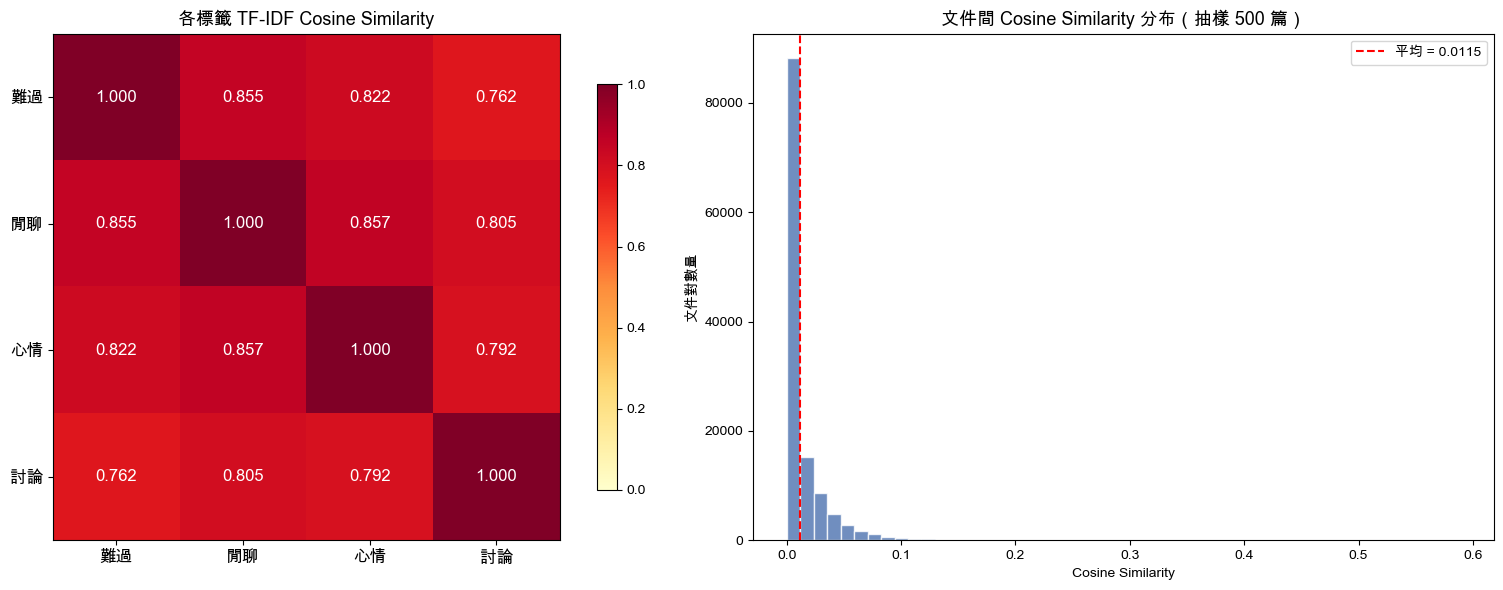

解讀：標籤間若相似度很高，代表不同標籤的用詞差異不大，分類器可能較難區分。


In [30]:
# P1-5c 視覺化：Cosine Similarity

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 標籤間熱力圖
im1 = axes[0].imshow(tag_cos_sim, cmap="YlOrRd", vmin=0, vmax=1)
axes[0].set_xticks(range(len(tag_groups)))
axes[0].set_yticks(range(len(tag_groups)))
axes[0].set_xticklabels(tag_groups, fontsize=12)
axes[0].set_yticklabels(tag_groups, fontsize=12)
for i in range(len(tag_groups)):
    for j in range(len(tag_groups)):
        axes[0].text(j, i, f"{tag_cos_sim[i,j]:.3f}", ha="center", va="center",
                     fontsize=12, color="white" if tag_cos_sim[i,j] > 0.5 else "black")
axes[0].set_title("各標籤 TF-IDF Cosine Similarity", fontsize=13)
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# 文件間分布直方圖
axes[1].hist(upper_tri, bins=50, color="#4C72B0", edgecolor="white", alpha=0.8)
axes[1].axvline(upper_tri.mean(), color="red", linestyle="--",
                label=f"平均 = {upper_tri.mean():.4f}")
axes[1].set_xlabel("Cosine Similarity")
axes[1].set_ylabel("文件對數量")
axes[1].set_title(f"文件間 Cosine Similarity 分布（抽樣 {sample_size} 篇）", fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

print("解讀：標籤間若相似度很高，代表不同標籤的用詞差異不大，分類器可能較難區分。")

## Part 1 小結

Part 1 從五個角度描述了語料的詞彙特徵：

1. **TF-IDF 關鍵詞**：辨識出在區分文章時最具權重的詞彙，並比較不同標籤的用詞差異。
2. **N-gram 統計**：找出常見的連續詞組合，補充單詞頻率缺少的詞序資訊。
3. **Bigram 網絡圖**：視覺化詞與詞之間的共現關係，辨識話題群落。
4. **Pairwise Correlation**：衡量同篇文章內的詞彙共現傾向，找出正相關與互斥的詞對。
5. **Cosine Similarity**：從文件層級衡量用詞相似度，觀察不同標籤間的區分度。

這些結果將在 Part 2（分類器能否區分標籤？）和 Part 3（隱含主題是什麼？）中進一步驗證與延伸。

# Part 2. 文件分類：監督式分類器與泛化測試

承接 Part 1 的前處理與 TF-IDF 矩陣，使用標題標籤（難過/閒聊/心情/討論）作為分類目標，訓練監督式分類器。

本段會完成：
1. **監督式分類器**：Logistic Regression、Random Forest、SVC、Decision Tree 四種模型。
2. **7:3 切分 + 5-fold CV**：評估模型穩定性。
3. **Confusion Matrix + 迴歸係數分析**：觀察分類錯誤模式與關鍵特徵。
4. **泛化測試（跨時間）**：用早期資料訓練、晚期資料測試，觀察模型是否穩定。
5. **對照組：規則式關鍵字分類**：與監督式方法做比較。

## 2-0. 匯入分類所需套件

Part 1 已匯入基礎套件，這裡補上 scikit-learn 的分類模組。

In [31]:
# 2-0 匯入分類套件

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

print("分類套件載入完成")

分類套件載入完成


## 2-1. 定義分類目標與資料準備

本研究以標題標籤作為分類目標。由於部分標籤的文章數過少（如「新聞」僅 123 篇），為避免樣本不均衡影響模型表現，這裡只保留文章數 ≥ 100 的標籤。

分類任務的設定：
- **特徵（X）**：Part 1 建好的 TF-IDF 矩陣。
- **標籤（y）**：標題標籤（難過、閒聊、心情、討論等）。
- **切分方式**：7:3 分層抽樣（stratified），確保各類別比例一致。

In [32]:
# 2-1 定義分類標籤與篩選樣本

# 只保留文章數 >= 100 的標籤
tag_counts = df_analysis["tag"].value_counts()
valid_tags = tag_counts[tag_counts >= 100].index.tolist()

print("各標籤文章數：")
for tag in valid_tags:
    print(f"  [{tag}]：{tag_counts[tag]} 篇")

# 篩選
mask = df_analysis["tag"].isin(valid_tags).values
X_all = tfidf_matrix[mask]
y_all_raw = df_analysis.loc[mask, "tag"].values

# 編碼標籤
le = LabelEncoder()
y_all = le.fit_transform(y_all_raw)
class_names = le.classes_

print(f"\n分類樣本：{X_all.shape[0]} 篇，{len(class_names)} 個類別")
print(f"類別名稱：{class_names.tolist()}")

各標籤文章數：
  [難過]：6198 篇
  [閒聊]：495 篇
  [心情]：365 篇
  [討論]：163 篇
  [問題]：153 篇
  [新聞]：123 篇

分類樣本：7497 篇，6 個類別
類別名稱：['問題', '心情', '新聞', '討論', '閒聊', '難過']


## 2-2. 7:3 切分訓練集與測試集

使用 `train_test_split` 做 70/30 分層切分，確保訓練集與測試集中各標籤的比例一致。
設定 `random_state=42` 確保結果可重現。

In [33]:
# 2-2 切分訓練集與測試集（7:3 分層抽樣）

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.3,
    random_state=42,
    stratify=y_all,
)

print(f"訓練集：{X_train.shape[0]} 篇")
print(f"測試集：{X_test.shape[0]} 篇")

print(f"\n訓練集各類別分布：")
for i, name in enumerate(class_names):
    count = (y_train == i).sum()
    print(f"  [{name}]：{count} 篇（{count/len(y_train):.1%}）")

print(f"\n測試集各類別分布：")
for i, name in enumerate(class_names):
    count = (y_test == i).sum()
    print(f"  [{name}]：{count} 篇（{count/len(y_test):.1%}）")

訓練集：5247 篇
測試集：2250 篇

訓練集各類別分布：
  [問題]：107 篇（2.0%）
  [心情]：256 篇（4.9%）
  [新聞]：86 篇（1.6%）
  [討論]：114 篇（2.2%）
  [閒聊]：346 篇（6.6%）
  [難過]：4338 篇（82.7%）

測試集各類別分布：
  [問題]：46 篇（2.0%）
  [心情]：109 篇（4.8%）
  [新聞]：37 篇（1.6%）
  [討論]：49 篇（2.2%）
  [閒聊]：149 篇（6.6%）
  [難過]：1860 篇（82.7%）


## 2-3. 訓練四種監督式分類器

同時訓練以下四種模型，比較其表現：

| 模型 | 全名 | 特性 |
|------|------|------|
| LR | Logistic Regression | 線性模型，可解釋性高，能看迴歸係數 |
| RF | Random Forest | 集成方法，不易過擬合，可看特徵重要性 |
| SVC | Linear SVC | 支持向量機，在高維稀疏特徵上表現好 |
| DT | Decision Tree | 決策樹，容易解釋但容易過擬合 |

每個模型先在測試集上評估，再用 5-fold CV 檢驗穩定性。

In [34]:
# 2-3 定義與訓練四種分類器

models = {
    "LR (Logistic Regression)": LogisticRegression(
        max_iter=1000, random_state=42, class_weight="balanced"
    ),
    "RF (Random Forest)": RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1
    ),
    "SVC (Linear SVC)": LinearSVC(
        max_iter=2000, random_state=42, class_weight="balanced"
    ),
    "DT (Decision Tree)": DecisionTreeClassifier(
        max_depth=20, random_state=42, class_weight="balanced"
    ),
}

# 訓練並記錄結果
results = {}
for name, model in models.items():
    print(f"訓練中：{name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "accuracy": acc,
    }
    print(f"  測試集 Accuracy：{acc:.4f}")

print("\n四種模型訓練完成")

訓練中：LR (Logistic Regression)...
  測試集 Accuracy：0.7324
訓練中：RF (Random Forest)...
  測試集 Accuracy：0.8351
訓練中：SVC (Linear SVC)...
  測試集 Accuracy：0.7964
訓練中：DT (Decision Tree)...
  測試集 Accuracy：0.6884

四種模型訓練完成


## 2-4. 測試集表現比較

先用長條圖比較四種模型的 Accuracy，再逐一查看 Classification Report（含 Precision、Recall、F1-score）。

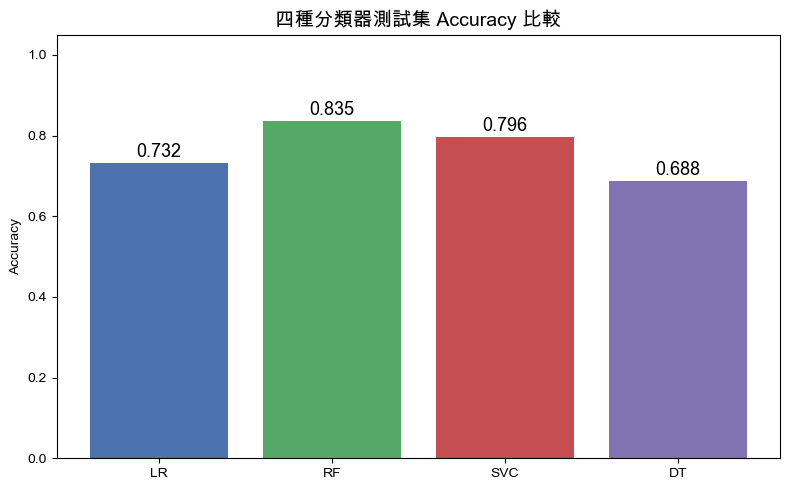

In [35]:
# 2-4a 視覺化：四種模型 Accuracy 比較

model_names = list(results.keys())
accuracies = [results[n]["accuracy"] for n in model_names]
short_names = ["LR", "RF", "SVC", "DT"]

plt.figure(figsize=(8, 5))
bars = plt.bar(short_names, accuracies, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{acc:.3f}", ha="center", va="bottom", fontsize=13)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("四種分類器測試集 Accuracy 比較", fontsize=14)
plt.tight_layout()
plt.show()

In [36]:
# 2-4b 各模型的 Classification Report

for name in model_names:
    print(f"\n{'='*60}")
    print(f"{name}")
    print("="*60)
    print(classification_report(y_test, results[name]["y_pred"],
                                target_names=class_names))


LR (Logistic Regression)
              precision    recall  f1-score   support

          問題       0.10      0.11      0.10        46
          心情       0.21      0.39      0.27       109
          新聞       0.76      0.78      0.77        37
          討論       0.09      0.10      0.09        49
          閒聊       0.14      0.19      0.16       149
          難過       0.91      0.83      0.87      1860

    accuracy                           0.73      2250
   macro avg       0.37      0.40      0.38      2250
weighted avg       0.79      0.73      0.76      2250


RF (Random Forest)
              precision    recall  f1-score   support

          問題       0.00      0.00      0.00        46
          心情       0.00      0.00      0.00       109
          新聞       1.00      0.46      0.63        37
          討論       0.00      0.00      0.00        49
          閒聊       1.00      0.01      0.03       149
          難過       0.83      1.00      0.91      1860

    accuracy                   

## 2-5. 5-fold 交叉驗證

單次 7:3 切分可能因為隨機分割而產生偏差。
5-fold CV 把資料分成 5 份，輪流用 4 份訓練、1 份測試，取 5 次的平均分數，更能反映模型的穩定性。

使用 `StratifiedKFold` 確保每一折的類別比例一致。

In [37]:
# 2-5 五折交叉驗證

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
print("5-fold Cross Validation 結果：\n")
print(f"{'模型':<30s} {'Mean Acc':>10s} {'Std':>10s} {'各折分數'}")
print("-" * 80)

for name, model_info in models.items():
    # 重新初始化模型（避免用已訓練過的）
    model_fresh = model_info.__class__(**model_info.get_params())
    scores = cross_val_score(model_fresh, X_all, y_all, cv=skf, scoring="accuracy")
    cv_results[name] = scores
    fold_str = ", ".join([f"{s:.3f}" for s in scores])
    print(f"{name:<30s} {scores.mean():>10.4f} {scores.std():>10.4f} [{fold_str}]")

5-fold Cross Validation 結果：

模型                               Mean Acc        Std 各折分數
--------------------------------------------------------------------------------
LR (Logistic Regression)           0.7380     0.0122 [0.716, 0.751, 0.735, 0.742, 0.746]
RF (Random Forest)                 0.8363     0.0010 [0.836, 0.835, 0.837, 0.837, 0.838]
SVC (Linear SVC)                   0.7985     0.0059 [0.787, 0.801, 0.798, 0.803, 0.804]
DT (Decision Tree)                 0.6671     0.0320 [0.683, 0.655, 0.626, 0.720, 0.651]


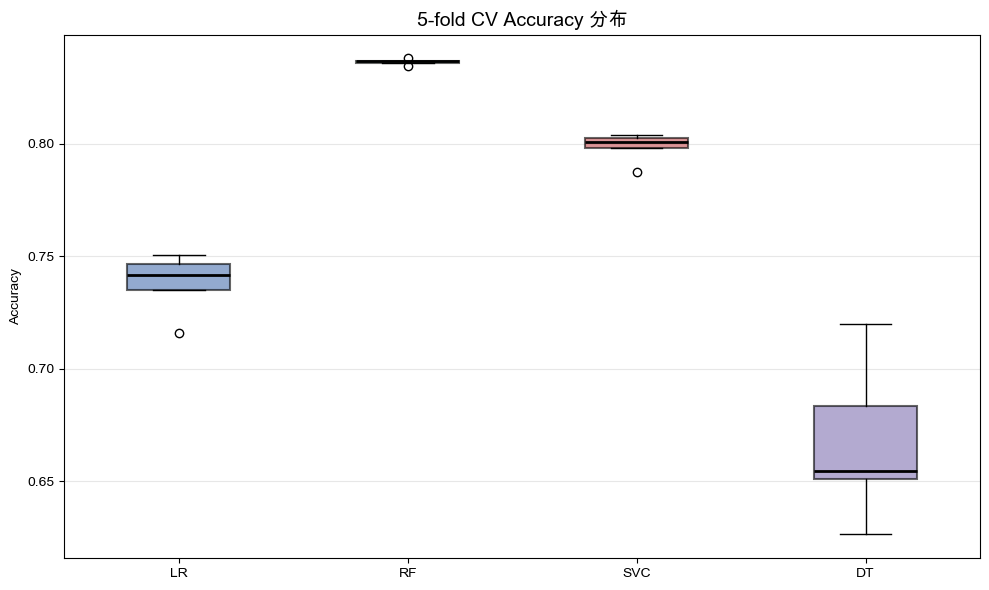

解讀：箱子越窄代表模型越穩定，中位線越高代表平均表現越好。


In [38]:
# 2-5b 視覺化：5-fold CV 各模型分數分布（箱型圖）

fig, ax = plt.subplots(figsize=(10, 6))
box_data = [cv_results[n] for n in model_names]
bp = ax.boxplot(box_data, labels=short_names, patch_artist=True,
                boxprops=dict(linewidth=1.5),
                medianprops=dict(color="black", linewidth=2))

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel("Accuracy")
ax.set_title("5-fold CV Accuracy 分布", fontsize=14)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("解讀：箱子越窄代表模型越穩定，中位線越高代表平均表現越好。")

## 2-6. Confusion Matrix

Confusion Matrix 能清楚呈現分類器把哪些類別搞混了：
- **對角線**上的數字越大越好，代表正確分類的數量。
- **非對角線**的數字代表錯誤分類（例如把「心情」誤判為「難過」）。

這裡會同時呈現四種模型的 Confusion Matrix，方便對照比較。

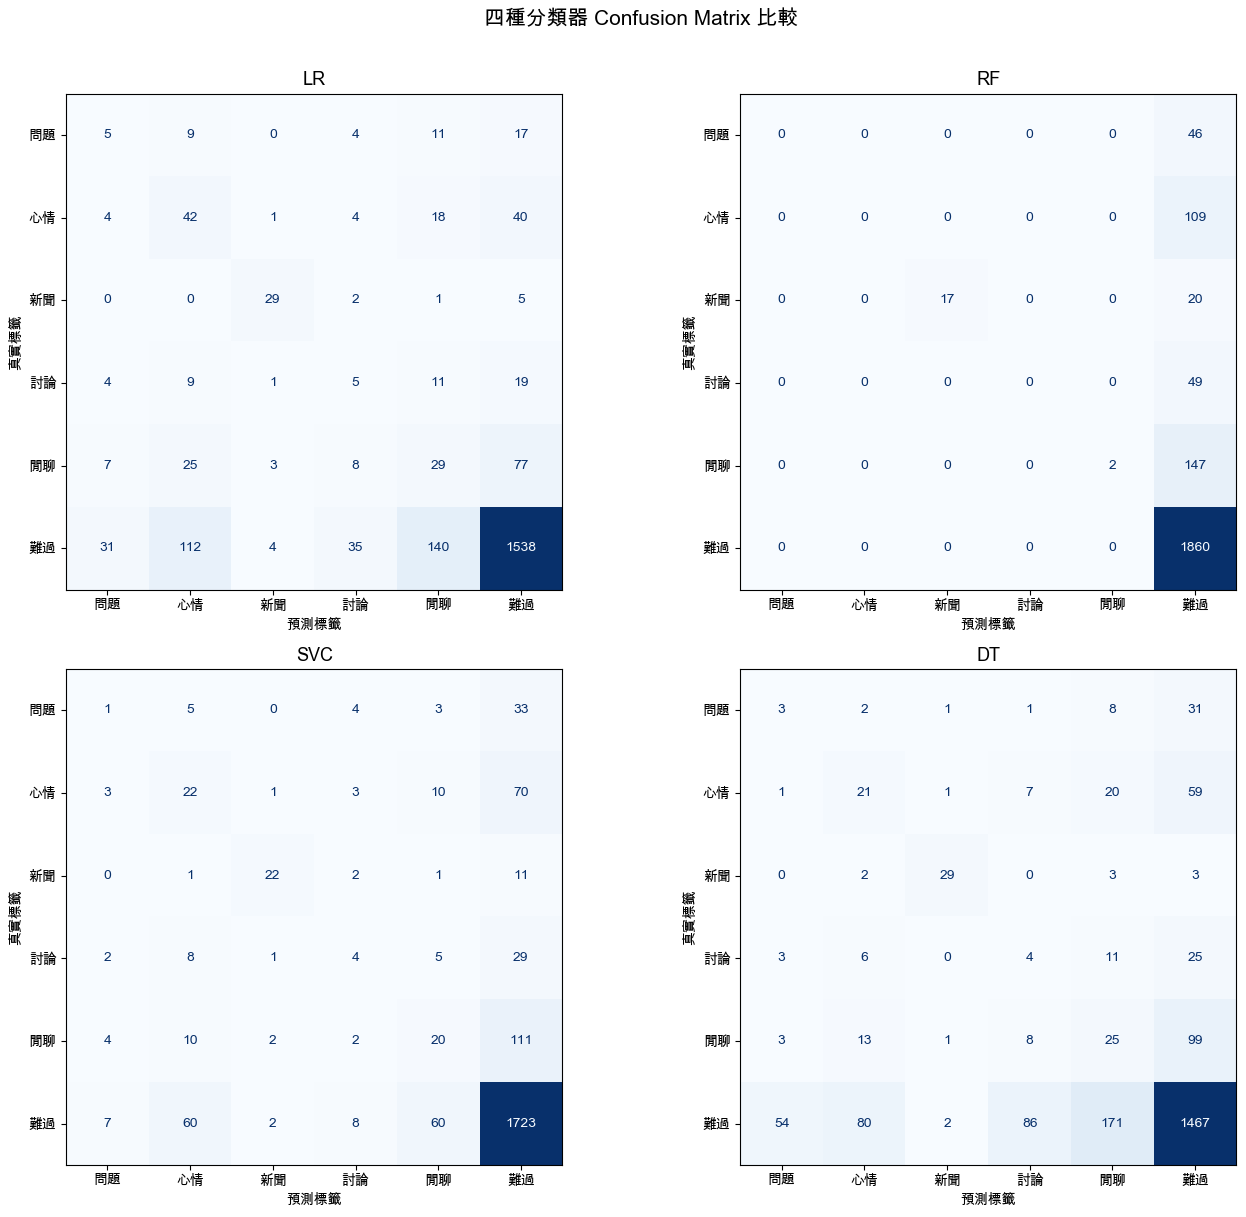

解讀：最常見的錯誤模式通常是把少數類（閒聊、心情、討論）誤判為多數類（難過），
這是因為資料本身就以「難過」為主（約 82%），即使使用 class_weight='balanced' 也難以完全消除。


In [39]:
# 2-6 視覺化：四種模型的 Confusion Matrix

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes_flat = axes.flatten()

for idx, name in enumerate(model_names):
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes_flat[idx], cmap="Blues", values_format="d", colorbar=False)
    axes_flat[idx].set_title(short_names[idx], fontsize=13)
    axes_flat[idx].set_xlabel("預測標籤")
    axes_flat[idx].set_ylabel("真實標籤")

plt.suptitle("四種分類器 Confusion Matrix 比較", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print("解讀：最常見的錯誤模式通常是把少數類（閒聊、心情、討論）誤判為多數類（難過），")
print("這是因為資料本身就以「難過」為主（約 82%），即使使用 class_weight='balanced' 也難以完全消除。")

## 2-7. 迴歸係數分析（Logistic Regression 特徵重要性）

Logistic Regression 的優勢在於可解釋性——每個類別的迴歸係數越大，代表該詞越能幫助辨識這個類別。

這裡會列出每個標籤最重要的 Top 15 關鍵詞，幫助理解「分類器是靠什麼詞來區分不同標籤的」。

In [40]:
# 2-7a LR 迴歸係數：各類別 Top 15 關鍵特徵

lr_model = results["LR (Logistic Regression)"]["model"]
coef = lr_model.coef_

print("Logistic Regression 各類別最重要的 Top 15 特徵詞：\n")
lr_top_features = {}
for i, tag_name in enumerate(class_names):
    top_idx = coef[i].argsort()[::-1][:15]
    top_words = tfidf_feature_names[top_idx]
    top_weights = coef[i][top_idx]
    lr_top_features[tag_name] = list(zip(top_words, top_weights))
    
    print(f"[{tag_name}]")
    for w, weight in zip(top_words, top_weights):
        bar = "█" * int(weight * 15) if weight > 0 else ""
        print(f"  {w:<8s} {weight:>7.3f} {bar}")
    print()

Logistic Regression 各類別最重要的 Top 15 特徵詞：

[問題]
  請問         2.779 █████████████████████████████████████████
  感情         2.606 ███████████████████████████████████████
  民進         2.405 ████████████████████████████████████
  以前         2.386 ███████████████████████████████████
  多少         2.331 ██████████████████████████████████
  客人         2.249 █████████████████████████████████
  小孩         2.231 █████████████████████████████████
  怎辦         2.166 ████████████████████████████████
  男孩         2.154 ████████████████████████████████
  領袖         2.105 ███████████████████████████████
  不太敢        2.061 ██████████████████████████████
  推薦         1.999 █████████████████████████████
  方式         1.987 █████████████████████████████
  所謂         1.981 █████████████████████████████
  快樂         1.917 ████████████████████████████

[心情]
  情緒         3.072 ██████████████████████████████████████████████
  心情         2.836 ██████████████████████████████████████████
  抒發         2.270 ██████████

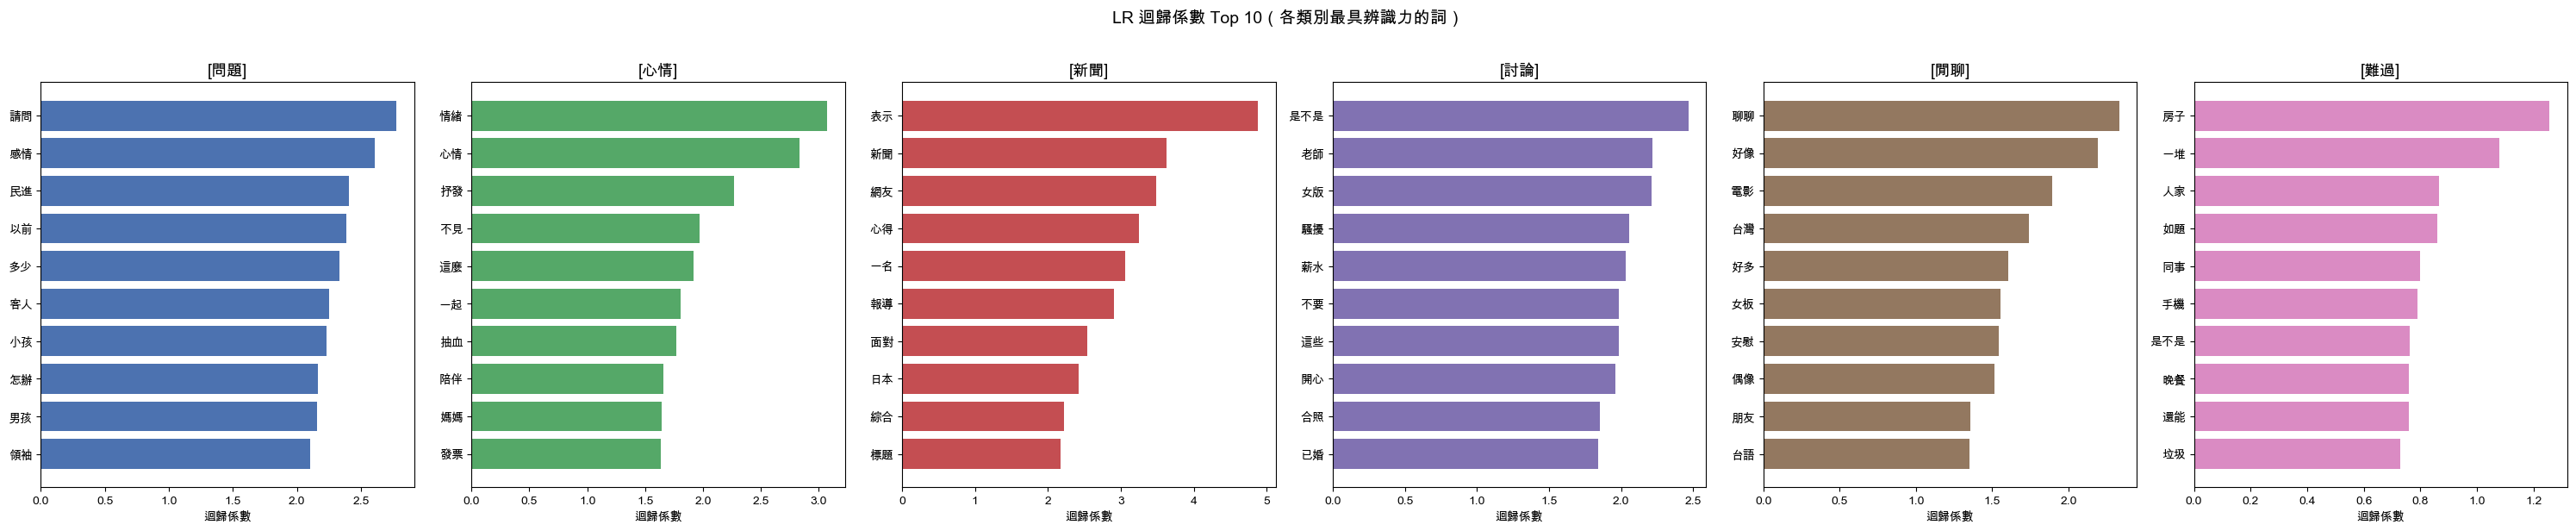

解讀：這些詞是分類器用來區分各標籤的關鍵線索。
例如若「分手」在「難過」類的係數最高，代表出現「分手」會強烈暗示這篇文章標籤是「難過」。


In [41]:
# 2-7b 視覺化：各類別 LR 迴歸係數 Top 10

n_classes = len(class_names)
fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 6))

if n_classes == 1:
    axes = [axes]

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#937860", "#DA8BC3"]

for i, tag_name in enumerate(class_names):
    top_idx = coef[i].argsort()[::-1][:10]
    words = tfidf_feature_names[top_idx]
    weights = coef[i][top_idx]
    
    axes[i].barh(range(9, -1, -1), weights, color=colors[i % len(colors)])
    axes[i].set_yticks(range(9, -1, -1))
    axes[i].set_yticklabels(words)
    axes[i].set_xlabel("迴歸係數")
    axes[i].set_title(f"[{tag_name}]", fontsize=13)

plt.suptitle("LR 迴歸係數 Top 10（各類別最具辨識力的詞）", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("解讀：這些詞是分類器用來區分各標籤的關鍵線索。")
print("例如若「分手」在「難過」類的係數最高，代表出現「分手」會強烈暗示這篇文章標籤是「難過」。")

## 2-8. Random Forest 特徵重要性

Random Forest 用另一種方式衡量特徵重要性——基於 Gini impurity 的下降量。
可以和 LR 迴歸係數互相對照：如果同一個詞在兩種方法中都排名靠前，代表它的辨識力更可靠。

表 2-8 Random Forest 特徵重要性 Top 30


,word,importance
0,心得,0.0102
1,報導,0.0100
2,表示,0.0089
3,標題,0.0064
4,新聞,0.0059
5,心情,0.0047
6,連結,0.0045
7,朋友,0.0042
8,不要,0.0040
9,網友,0.0038


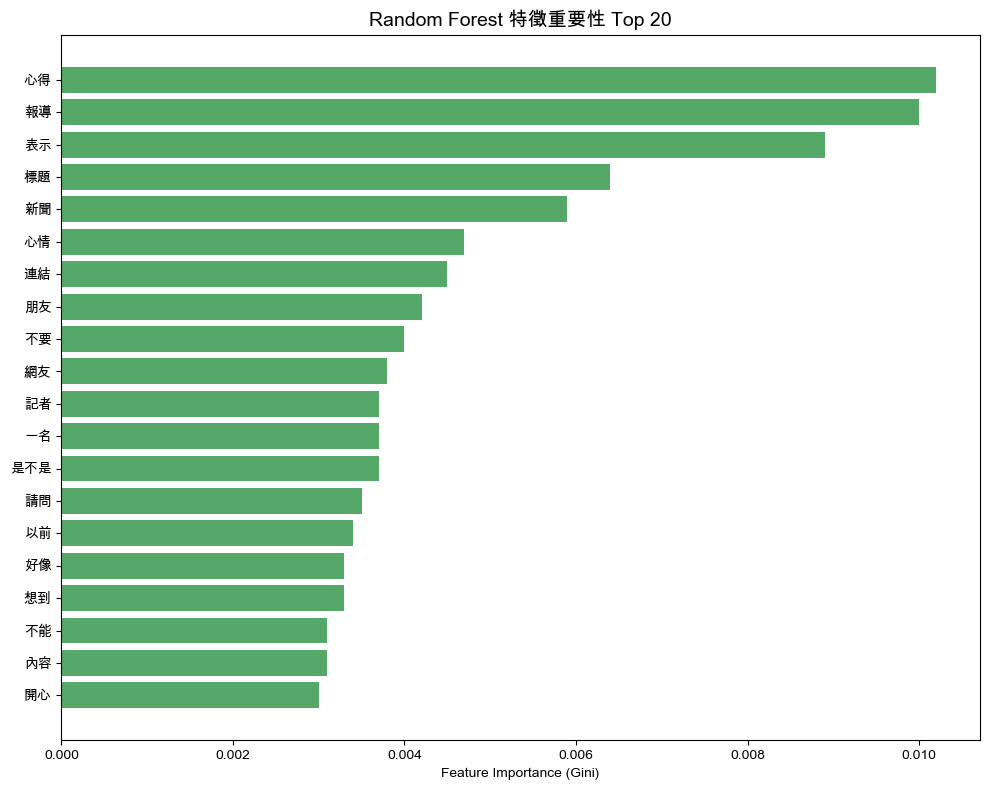

In [42]:
# 2-8 Random Forest 特徵重要性 Top 30

rf_model = results["RF (Random Forest)"]["model"]
rf_importances = rf_model.feature_importances_
rf_top_idx = rf_importances.argsort()[::-1][:30]

rf_importance_df = pd.DataFrame({
    "word": tfidf_feature_names[rf_top_idx],
    "importance": rf_importances[rf_top_idx].round(4),
})

print("表 2-8 Random Forest 特徵重要性 Top 30")
display(rf_importance_df)

# 視覺化
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(19, -1, -1), rf_importance_df["importance"].head(20), color="#55A868")
ax.set_yticks(range(19, -1, -1))
ax.set_yticklabels(rf_importance_df["word"].head(20))
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Random Forest 特徵重要性 Top 20", fontsize=14)
plt.tight_layout()
plt.show()

## 2-9. 泛化測試（跨時間）

前面的 7:3 切分是隨機的，訓練集和測試集來自同一時間段。
但在實務上，模型可能需要預測「未來」的文章——如果用詞風格隨時間改變，模型就可能失效。

泛化測試的做法：
- **訓練集**：2021–2023 年的文章。
- **測試集**：2024–2025 年的文章。

如果模型在這種切分下表現接近隨機切分，代表用詞特徵跨時間穩定；若大幅下降，代表存在時間漂移（temporal drift）。

In [43]:
# 2-9a 依時間切分訓練集與測試集

# 取得年份
years = df_analysis.loc[mask.nonzero()[0] if hasattr(mask, 'nonzero') else np.where(mask)[0], "year"].values

# 訓練：2021-2023，測試：2024-2025
train_time_mask = years <= 2023
test_time_mask = years >= 2024

X_train_time = X_all[train_time_mask]
X_test_time = X_all[test_time_mask]
y_train_time = y_all[train_time_mask]
y_test_time = y_all[test_time_mask]

print(f"跨時間切分：")
print(f"  訓練集（2021–2023）：{X_train_time.shape[0]} 篇")
print(f"  測試集（2024–2025）：{X_test_time.shape[0]} 篇")

if X_test_time.shape[0] == 0:
    print("\n測試集為空，改用最後 20% 時間的文章作為測試集")
    cutoff = int(len(y_all) * 0.8)
    X_train_time = X_all[:cutoff]
    X_test_time = X_all[cutoff:]
    y_train_time = y_all[:cutoff]
    y_test_time = y_all[cutoff:]
    print(f"  訓練集（前 80%）：{X_train_time.shape[0]} 篇")
    print(f"  測試集（後 20%）：{X_test_time.shape[0]} 篇")

跨時間切分：
  訓練集（2021–2023）：6278 篇
  測試集（2024–2025）：1219 篇


In [44]:
# 2-9b 泛化測試：四種模型在跨時間切分上的表現

print("泛化測試結果（跨時間切分）：\n")
print(f"{'模型':<30s} {'隨機切分 Acc':>14s} {'跨時間 Acc':>14s} {'差異':>10s}")
print("-" * 70)

generalization_results = {}
for name, model_info in models.items():
    model_fresh = model_info.__class__(**model_info.get_params())
    model_fresh.fit(X_train_time, y_train_time)
    y_pred_time = model_fresh.predict(X_test_time)
    acc_time = accuracy_score(y_test_time, y_pred_time)
    acc_random = results[name]["accuracy"]
    diff = acc_time - acc_random
    generalization_results[name] = {
        "acc_random": acc_random,
        "acc_time": acc_time,
        "y_pred": y_pred_time,
    }
    print(f"{name:<30s} {acc_random:>14.4f} {acc_time:>14.4f} {diff:>+10.4f}")

泛化測試結果（跨時間切分）：

模型                                   隨機切分 Acc        跨時間 Acc         差異
----------------------------------------------------------------------
LR (Logistic Regression)               0.7324         0.7268    -0.0056
RF (Random Forest)                     0.8351         0.8039    -0.0312
SVC (Linear SVC)                       0.7964         0.7711    -0.0253
DT (Decision Tree)                     0.6884         0.7153    +0.0269


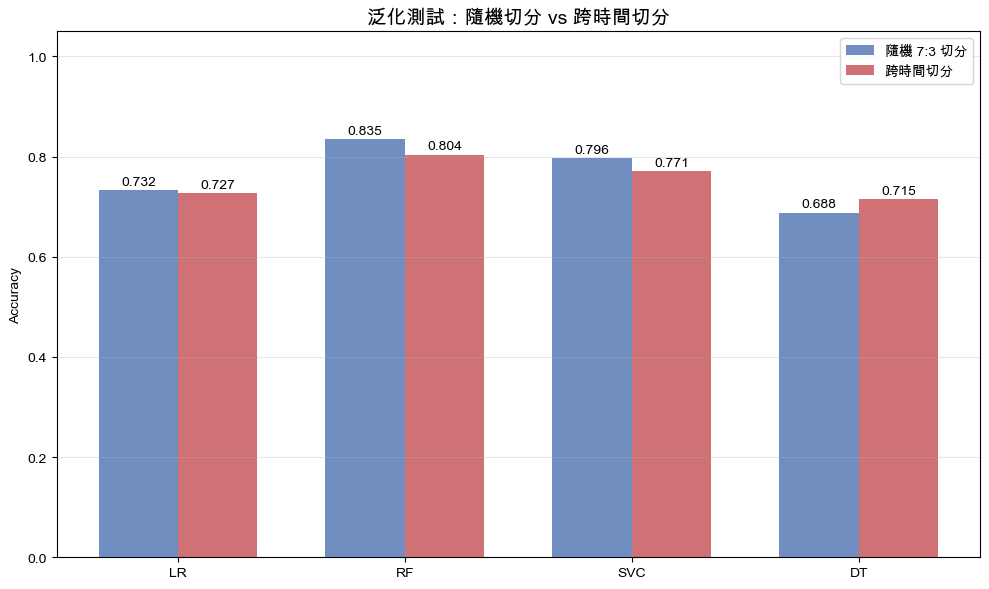

解讀：若跨時間 Accuracy 與隨機切分接近，代表用詞特徵跨年穩定；
若明顯下降，代表不同年份的用詞風格有所轉變。


In [45]:
# 2-9c 視覺化：隨機切分 vs 跨時間切分 Accuracy 比較

x_pos = np.arange(len(short_names))
width = 0.35

acc_random = [generalization_results[n]["acc_random"] for n in model_names]
acc_time = [generalization_results[n]["acc_time"] for n in model_names]

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x_pos - width/2, acc_random, width, label="隨機 7:3 切分", color="#4C72B0", alpha=0.8)
bars2 = ax.bar(x_pos + width/2, acc_time, width, label="跨時間切分", color="#C44E52", alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x_pos)
ax.set_xticklabels(short_names)
ax.set_ylabel("Accuracy")
ax.set_title("泛化測試：隨機切分 vs 跨時間切分", fontsize=14)
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("解讀：若跨時間 Accuracy 與隨機切分接近，代表用詞特徵跨年穩定；")
print("若明顯下降，代表不同年份的用詞風格有所轉變。")

## 2-10. 跨時間切分的 Confusion Matrix

針對表現最好的模型，進一步觀察在跨時間切分下的分類錯誤模式。

跨時間切分表現最好的模型：RF (Random Forest)
Accuracy：0.8039

              precision    recall  f1-score   support

          問題       0.00      0.00      0.00        45
          心情       0.00      0.00      0.00        66
          新聞       1.00      0.60      0.75        20
          討論       0.00      0.00      0.00        30
          閒聊       0.00      0.00      0.00        90
          難過       0.80      1.00      0.89       968

    accuracy                           0.80      1219
   macro avg       0.30      0.27      0.27      1219
weighted avg       0.65      0.80      0.72      1219



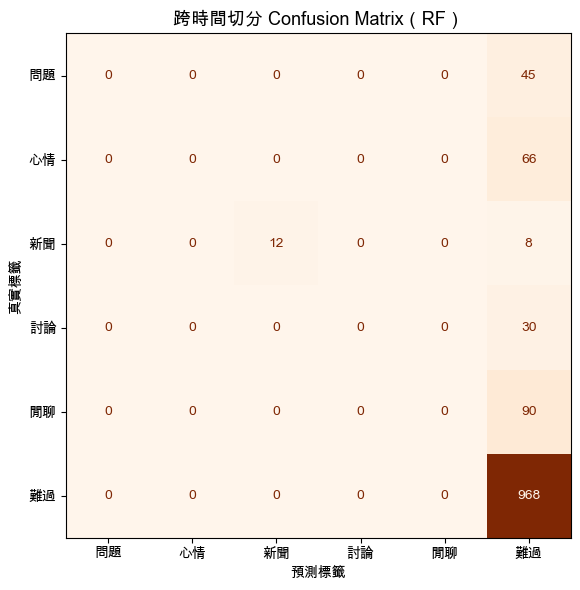

In [46]:
# 2-10 跨時間切分的 Confusion Matrix（最佳模型）

# 找出跨時間表現最好的模型
best_name = max(generalization_results, key=lambda n: generalization_results[n]["acc_time"])
best_pred = generalization_results[best_name]["y_pred"]
best_short = short_names[model_names.index(best_name)]

print(f"跨時間切分表現最好的模型：{best_name}")
print(f"Accuracy：{generalization_results[best_name]['acc_time']:.4f}\n")
print(classification_report(y_test_time, best_pred, target_names=class_names))

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test_time, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Oranges", values_format="d", colorbar=False)
ax.set_title(f"跨時間切分 Confusion Matrix（{best_short}）", fontsize=13)
ax.set_xlabel("預測標籤")
ax.set_ylabel("真實標籤")
plt.tight_layout()
plt.show()

## 2-11. 對照組：規則式關鍵字分類

規則式分類不使用機器學習，而是靠人工定義的關鍵字規則來判斷類別。
這種方法的優點是完全可解釋，缺點是覆蓋率有限且難以處理模糊案例。

把它放在這裡作為對照組，可以回答一個問題：
**監督式分類器比人工規則好多少？**

In [47]:
# 2-11a 定義規則式分類函式

def rule_based_classify(text, title=""):
    """基於關鍵字的規則式分類。"""
    combined = str(title) + " " + str(text)
    
    # 規則順序很重要：先判斷較具體的類別
    discussion_kw = ["大家", "有人", "怎麼看", "如何", "是不是", "有沒有", "會不會", "請問"]
    chat_kw = ["閒聊", "無聊", "睡不著", "日常", "分享", "推薦", "清單"]
    mood_kw = ["心情", "抒發", "低落", "鬱悶", "煩躁", "感慨"]
    sad_kw = ["難過", "哭", "分手", "失戀", "崩潰", "想哭", "傷心", "痛苦", "離開", "走了"]
    
    if any(kw in combined for kw in discussion_kw):
        return "討論"
    if any(kw in combined for kw in chat_kw):
        return "閒聊"
    if any(kw in combined for kw in mood_kw):
        return "心情"
    if any(kw in combined for kw in sad_kw):
        return "難過"
    return "難過"  # 預設（因為大部分都是難過）

# 對測試集做規則式分類
df_test_subset = df_analysis.iloc[
    np.where(mask)[0]  # 取出有效樣本的原始 index
][: len(y_all)]  # 對齊長度

# 用 7:3 的測試集索引
test_indices = np.arange(len(y_all))
_, test_idx = train_test_split(test_indices, test_size=0.3, random_state=42, stratify=y_all)

y_pred_rule = []
for idx in test_idx:
    row = df_analysis.iloc[np.where(mask)[0][idx]]
    pred = rule_based_classify(row["clean_content"], row.get("clean_title", ""))
    y_pred_rule.append(pred)

y_pred_rule_encoded = le.transform(y_pred_rule)
acc_rule = accuracy_score(y_test, y_pred_rule_encoded)

print(f"規則式分類 Accuracy：{acc_rule:.4f}")
print(f"\n{classification_report(y_test, y_pred_rule_encoded, target_names=class_names)}")

規則式分類 Accuracy：0.4338

              precision    recall  f1-score   support

          問題       0.00      0.00      0.00        46
          心情       0.15      0.06      0.09       109
          新聞       0.00      0.00      0.00        37
          討論       0.03      0.73      0.06        49
          閒聊       0.09      0.04      0.06       149
          難過       0.88      0.50      0.64      1860

    accuracy                           0.43      2250
   macro avg       0.19      0.22      0.14      2250
weighted avg       0.74      0.43      0.54      2250



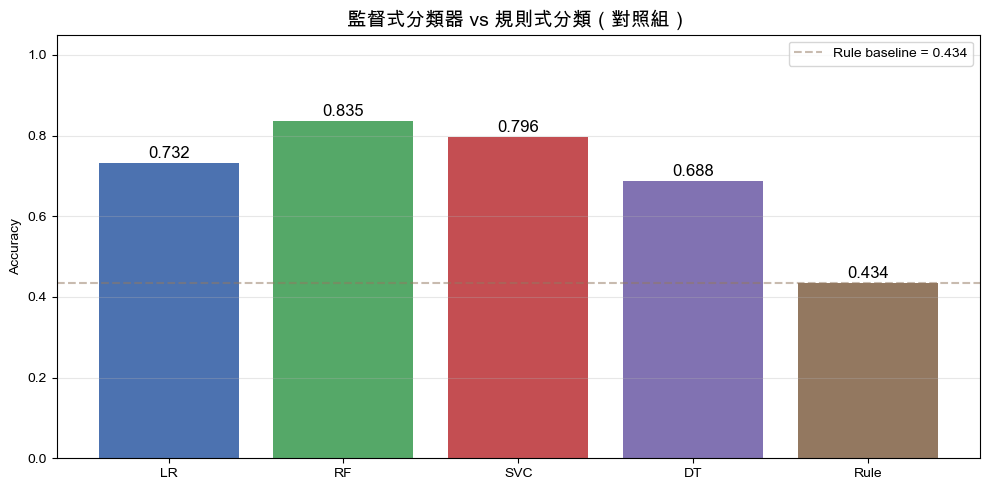

解讀：監督式分類器相對規則式分類的提升幅度，代表 TF-IDF 特徵的額外辨識力。


In [48]:
# 2-11b 視覺化：監督式 vs 規則式 Accuracy 比較

all_methods = short_names + ["Rule"]
all_accs = [results[n]["accuracy"] for n in model_names] + [acc_rule]
all_colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#937860"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(all_methods, all_accs, color=all_colors)
for bar, acc in zip(bars, all_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{acc:.3f}", ha="center", va="bottom", fontsize=12)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("監督式分類器 vs 規則式分類（對照組）", fontsize=14)
ax.axhline(y=acc_rule, color="#937860", linestyle="--", alpha=0.5, label=f"Rule baseline = {acc_rule:.3f}")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("解讀：監督式分類器相對規則式分類的提升幅度，代表 TF-IDF 特徵的額外辨識力。")

## Part 2 小結

Part 2 從四個層次評估了文件分類的可行性：

1. **7:3 切分測試**：四種監督式分類器的 Accuracy 比較，觀察哪種模型最適合本資料。
2. **5-fold CV**：驗證模型穩定性，避免單次切分的偶然偏差。
3. **Confusion Matrix + 迴歸係數**：深入了解分類器的錯誤模式與決策依據。
4. **泛化測試（跨時間）**：檢驗模型是否在不同時間段仍然有效。
5. **對照組（規則式分類）**：量化監督式方法相對於人工規則的提升幅度。

主要發現：
- 由於資料高度不均衡（「難過」佔約 82%），分類器容易把少數類誤判為「難過」。
- 使用 `class_weight="balanced"` 能部分緩解不均衡問題，但無法完全消除。
- LR 的迴歸係數與 RF 的特徵重要性可以互相對照，找出真正有辨識力的關鍵詞。

---
# Part 3. 主題模型：LDA、最佳主題數與視覺化

這份 notebook 承接 Part 1 的前處理與斷詞結果，使用 **LDA（Latent Dirichlet Allocation）** 發掘「難過」貼文中隱含的主題結構。

本段會完成：
1. **gensim LDA**：建立主題模型，觀察語料中潛藏的主題分布。
2. **Perplexity / C_NPMI 掃 k**：用量化指標找出最佳主題數。
3. **pyLDAvis 視覺化**：互動式呈現主題間的關係與各主題的關鍵詞。
4. **GuidedLDA（加分）**：用種子詞引導主題方向，提升可解釋性。

核心問題：**PTT WomenTalk 的「難過」貼文中，隱含哪些主要主題？**

## 3-0. 安裝與匯入主題模型套件

LDA 使用 `gensim` 實作，視覺化使用 `pyLDAvis`。
若環境尚未安裝，請先執行安裝格。

In [49]:
# 3-0a 安裝套件（若已安裝可跳過）
# !pip install gensim pyLDAvis

In [51]:
# 3-0b 匯入主題模型套件
!pip install gensim pyLDAvis
import gensim
from gensim import corpora
from gensim.models import LdaMulticore, CoherenceModel

try:
    import pyLDAvis
    import pyLDAvis.gensim_models as gensimvis
    pyldavis_available = True
    print("pyLDAvis 可用")
except ImportError:
    pyldavis_available = False
    print("pyLDAvis 未安裝，視覺化段落將自動略過")
    print("   安裝方式：!pip install pyLDAvis")

try:
    import guidedlda
    guidedlda_available = True
    print("GuidedLDA 可用")
except ImportError:
    guidedlda_available = False
    print("GuidedLDA 未安裝，加分段落將自動略過")
    print("   安裝方式：!pip install guidedlda")

print(f"\ngensim 版本：{gensim.__version__}")
print("主題模型套件載入完成")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.4/24.4 MB 6.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 6.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [pyLDAvis]3/4 [pyLDAvis]
pyLDAvis 可用
GuidedLDA 未安裝，加分段落將自動略過
   安裝方式：!pip install guidedlda

gensim 版本：4.4.0
主題模型套件載入完成


## 3-1. 建立 gensim 語料格式

LDA 的輸入不是 TF-IDF 矩陣，而是 **Bag of Words（詞袋）** 格式。
這裡需要把 Part 1 產出的斷詞結果（`tokens`）轉換成 gensim 要求的格式：

1. **Dictionary**：建立「詞 ↔ ID」的對照表。
2. **Corpus**：把每篇文章轉成 `[(詞ID, 詞頻), ...]` 的列表。

同時會過濾極高頻（出現在超過 70% 文章）和極低頻（出現不到 5 篇）的詞，避免干擾主題辨識。

In [52]:
# 3-1 建立 gensim Dictionary 與 Corpus

# 取出斷詞結果（使用 df_analysis 的 tokens）
texts = df_analysis["tokens"].tolist()

# 建立詞典
dictionary = corpora.Dictionary(texts)
print(f"過濾前詞彙數：{len(dictionary)}")

# 過濾極端頻率的詞
dictionary.filter_extremes(
    no_below=5,     # 至少出現在 5 篇
    no_above=0.7,   # 不超過 70% 的文章
    keep_n=5000,    # 最多保留 5000 個詞
)
print(f"過濾後詞彙數：{len(dictionary)}")

# 建立 Bag of Words 語料
corpus = [dictionary.doc2bow(text) for text in texts]

print(f"語料筆數：{len(corpus)}")
print(f"\n前 3 篇 BoW 預覽（前 5 個詞）：")
for i in range(3):
    preview = [(dictionary[wid], freq) for wid, freq in corpus[i][:5]]
    print(f"  文章 {i}: {preview}")

過濾前詞彙數：77968
過濾後詞彙數：5000
語料筆數：7541

前 3 篇 BoW 預覽（前 5 個詞）：
  文章 0: [('一天', 1), ('不到', 1), ('不足', 2), ('太太', 1), ('平均', 1)]
  文章 1: [('不到', 1), ('一打', 1), ('一條', 1), ('一次', 1), ('一陣', 1)]
  文章 2: [('是不是', 2), ('聯絡', 1), ('一方面', 1), ('一起', 1), ('交到', 1)]


## 3-2. Perplexity / Coherence 掃描最佳主題數 k

LDA 需要事先指定主題數 k，但最佳的 k 是多少並不確定。
這裡用兩個指標來輔助決定：

| 指標 | 說明 | 怎麼看 |
|------|------|--------|
| **Perplexity** | 模型對語料的困惑度 | 越低越好（但容易過擬合，不能只看它） |
| **C_NPMI Coherence** | 主題內的詞彙語義連貫度 | 越高越好（更可靠的指標） |

掃描範圍設為 k = 3 到 15，每個 k 訓練一次 LDA，記錄兩個指標。
最佳 k 通常選 **Coherence 最高**（或明顯轉折）的位置。

In [53]:
# 3-2 掃描最佳主題數 k

k_range = range(3, 16)
perplexity_scores = []
coherence_scores = []

print("開始掃描 k = 3 ~ 15（每個 k 約需 30–60 秒）...\n")

for k in k_range:
    lda_temp = LdaMulticore(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=5,
        workers=2,
    )
    
    # Perplexity（越低越好）
    perp = lda_temp.log_perplexity(corpus)
    perplexity_scores.append(perp)
    
    # Coherence - C_NPMI（越高越好）
    cm = CoherenceModel(
        model=lda_temp,
        texts=texts,
        dictionary=dictionary,
        coherence="c_npmi",
    )
    coh = cm.get_coherence()
    coherence_scores.append(coh)
    
    print(f"  k={k:2d}  |  Perplexity: {perp:.4f}  |  C_NPMI: {coh:.4f}")

print("\n掃描完成")

開始掃描 k = 3 ~ 15（每個 k 約需 30–60 秒）...

  k= 3  |  Perplexity: -7.8555  |  C_NPMI: -0.0113
  k= 4  |  Perplexity: -7.8772  |  C_NPMI: -0.0104
  k= 5  |  Perplexity: -7.8934  |  C_NPMI: -0.0128
  k= 6  |  Perplexity: -7.9035  |  C_NPMI: -0.0094
  k= 7  |  Perplexity: -7.9200  |  C_NPMI: -0.0064
  k= 8  |  Perplexity: -7.9395  |  C_NPMI: -0.0093
  k= 9  |  Perplexity: -7.9483  |  C_NPMI: -0.0096
  k=10  |  Perplexity: -7.9642  |  C_NPMI: -0.0107
  k=11  |  Perplexity: -7.9806  |  C_NPMI: -0.0096
  k=12  |  Perplexity: -7.9936  |  C_NPMI: -0.0188
  k=13  |  Perplexity: -8.0082  |  C_NPMI: -0.0227
  k=14  |  Perplexity: -8.0314  |  C_NPMI: -0.0193
  k=15  |  Perplexity: -8.0372  |  C_NPMI: -0.0228

掃描完成


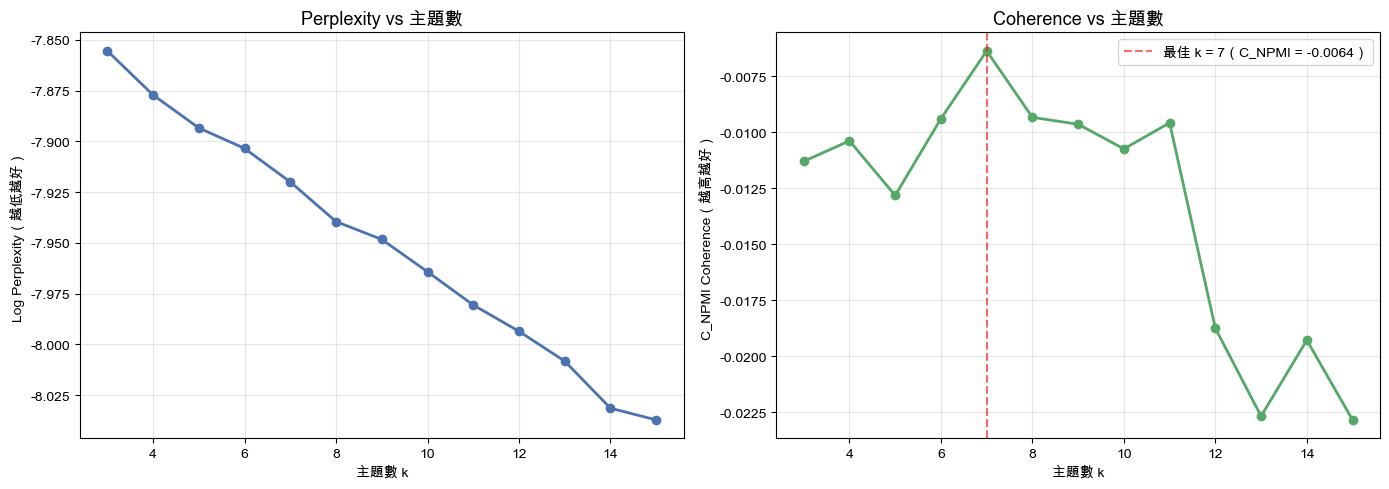


根據 C_NPMI，建議主題數 k = 7
若多個 k 的 Coherence 接近，可選較小的 k 以提升可解釋性。


In [54]:
# 3-2b 視覺化：Perplexity & Coherence vs k

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Perplexity
axes[0].plot(list(k_range), perplexity_scores, marker="o", color="#4C72B0", linewidth=2)
axes[0].set_xlabel("主題數 k")
axes[0].set_ylabel("Log Perplexity（越低越好）")
axes[0].set_title("Perplexity vs 主題數", fontsize=13)
axes[0].grid(alpha=0.3)

# Coherence
axes[1].plot(list(k_range), coherence_scores, marker="o", color="#55A868", linewidth=2)
best_k = list(k_range)[np.argmax(coherence_scores)]
best_coherence = max(coherence_scores)
axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.6,
                label=f"最佳 k = {best_k}（C_NPMI = {best_coherence:.4f}）")
axes[1].set_xlabel("主題數 k")
axes[1].set_ylabel("C_NPMI Coherence（越高越好）")
axes[1].set_title("Coherence vs 主題數", fontsize=13)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n根據 C_NPMI，建議主題數 k = {best_k}")
print("若多個 k 的 Coherence 接近，可選較小的 k 以提升可解釋性。")

## 3-3. 使用最佳 k 訓練正式 LDA 模型

根據 Coherence 掃描結果，使用最佳 k 值訓練正式的 LDA 模型。
這裡增加 `passes`（迭代次數）以提升模型品質。

In [55]:
# 3-3 訓練正式 LDA 模型

print(f"使用 k = {best_k} 訓練正式 LDA 模型...")

lda_model = LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_k,
    random_state=42,
    passes=15,       # 增加迭代次數
    workers=2,
    alpha="asymmetric",
    eta="auto",
)

print(f"LDA 模型訓練完成（{best_k} 個主題）")

使用 k = 7 訓練正式 LDA 模型...
LDA 模型訓練完成（7 個主題）


## 3-4. 主題內容解讀

每個主題是一組有高機率的詞彙，這些詞共同定義了該主題的語義方向。

這裡會呈現：
1. **每個主題的 Top 15 關鍵詞與權重**——理解每個主題在說什麼。
2. **橫向長條圖**——視覺化各主題的關鍵詞權重分布。

In [60]:
# 3-4a 列出各主題的 Top 15 關鍵詞

topic_labels = {
    0: "朋友同事都好累，人際關係好崩潰",
    1: "身體不適真的累，看醫生也好崩潰",
    2: "上班薪水都很累，人生現實好崩潰",
    3: "日常小事一直堆，情緒突然就破碎",
    4: "新聞社會看了累，公共議題好無力",
    5: "戀愛分手都會累，感情世界好破碎",
    6: "家人期待一直追，情緒內耗好疲憊",
}

print(f"LDA 模型共 {best_k} 個主題，各主題 Top 15 關鍵詞：\n")

topic_keywords = {}
for topic_id in range(best_k):
    top_words = lda_model.show_topic(topic_id, topn=15)
    topic_keywords[topic_id] = top_words
    label = topic_labels.get(topic_id, "未命名")
    words_str = ", ".join([f"{w}({p:.3f})" for w, p in top_words])
    print(f"主題 {topic_id}【{label}】")
    print(f"  {words_str}")
    print()

LDA 模型共 7 個主題，各主題 Top 15 關鍵詞：

主題 0【朋友同事都好累，人際關係好崩潰】
  朋友(0.015), 結果(0.008), 是不是(0.008), 發現(0.007), 喜歡(0.007), 直接(0.007), 這麼(0.006), 手機(0.005), 不要(0.005), 各位(0.005), 同事(0.005), 好像(0.004), 女孩(0.004), 根本(0.004), 不能(0.004)

主題 1【身體不適真的累，看醫生也好崩潰】
  醫生(0.010), 結果(0.009), 上班(0.008), 啊啊啊(0.008), 晚上(0.007), 發現(0.006), 每天(0.005), 疫苗(0.005), 早上(0.005), 如題(0.005), 醫院(0.005), 好吃(0.005), 不能(0.004), 手術(0.004), 不想(0.004)

主題 2【上班薪水都很累，人生現實好崩潰】
  工作(0.026), 公司(0.014), 同事(0.013), 上班(0.009), 薪水(0.008), 主管(0.008), 房子(0.008), 台灣(0.007), 老闆(0.007), 結果(0.006), 只有(0.005), 不要(0.005), 是不是(0.004), 人生(0.004), 只能(0.004)

主題 3【日常小事一直堆，情緒突然就破碎】
  老師(0.013), 可是(0.008), 時間(0.008), 回家(0.006), 起來(0.005), 廁所(0.005), 結果(0.005), 寵物(0.005), 男生(0.005), 同學(0.005), 當時(0.004), 甚麼(0.004), 學校(0.004), 小孩(0.004), 一堆(0.004)

主題 4【新聞社會看了累，公共議題好無力】
  台灣(0.010), 新聞(0.007), 社會(0.007), 這些(0.006), 不要(0.005), 女性(0.004), 政府(0.004), 支持(0.004), 表示(0.003), 認為(0.003), 那些(0.003), 甚至(0.003), 心理(0.003), 事件(0.003), 無法(0.003)

主題 5【戀愛分手都會累，感情世界好破碎】

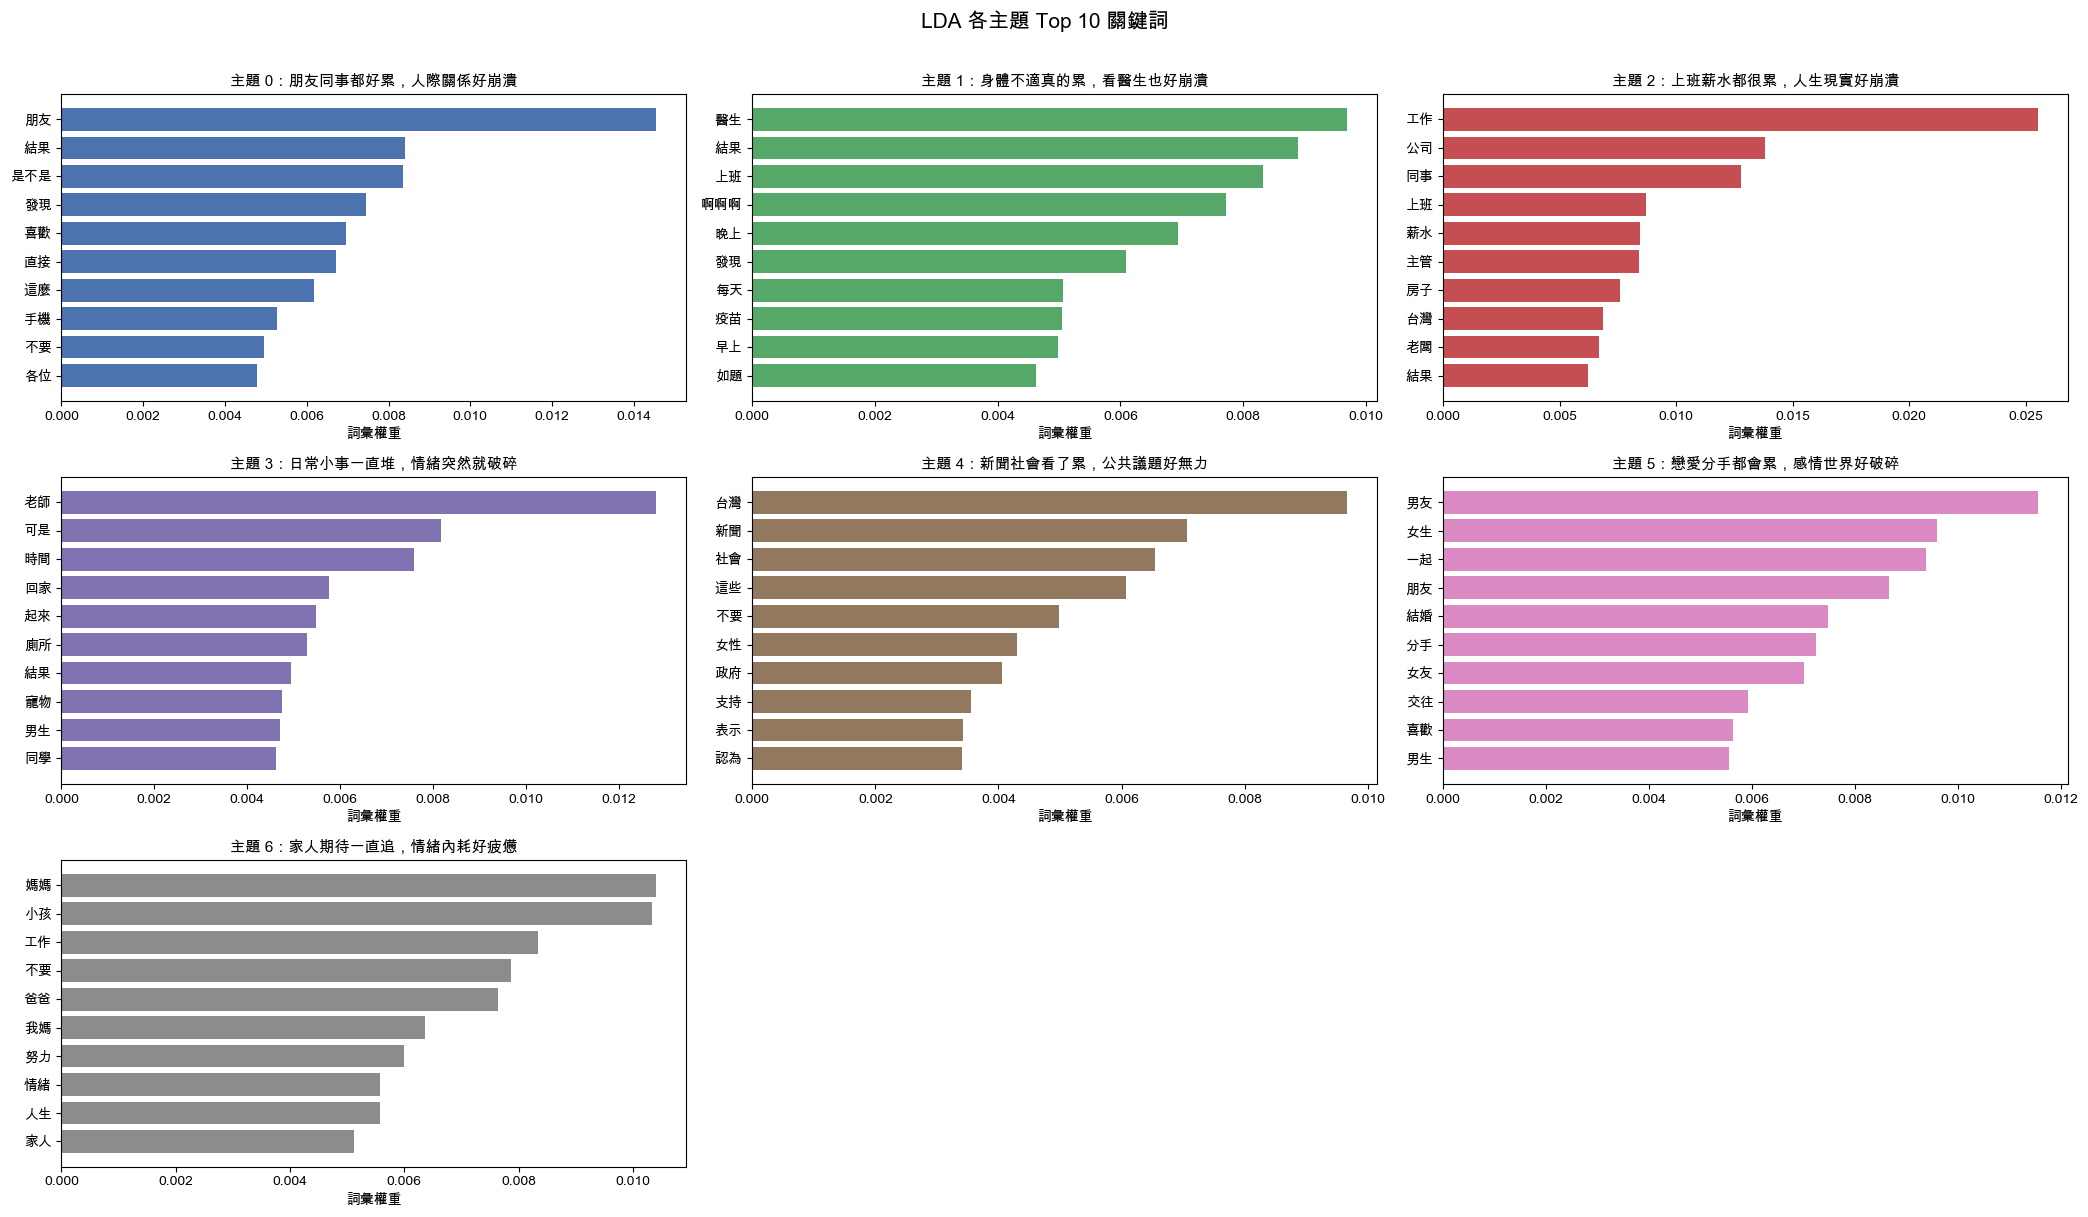

各主題標籤：
  主題 0：朋友同事都好累，人際關係好崩潰（朋友, 結果, 是不是）
  主題 1：身體不適真的累，看醫生也好崩潰（醫生, 結果, 上班）
  主題 2：上班薪水都很累，人生現實好崩潰（工作, 公司, 同事）
  主題 3：日常小事一直堆，情緒突然就破碎（老師, 可是, 時間）
  主題 4：新聞社會看了累，公共議題好無力（台灣, 新聞, 社會）
  主題 5：戀愛分手都會累，感情世界好破碎（男友, 女生, 一起）
  主題 6：家人期待一直追，情緒內耗好疲憊（媽媽, 小孩, 工作）


In [58]:
# 3-4b 視覺化：各主題 Top 10 關鍵詞權重

topic_labels = {
    0: "朋友同事都好累，人際關係好崩潰",
    1: "身體不適真的累，看醫生也好崩潰",
    2: "上班薪水都很累，人生現實好崩潰",
    3: "日常小事一直堆，情緒突然就破碎",
    4: "新聞社會看了累，公共議題好無力",
    5: "戀愛分手都會累，感情世界好破碎",
    6: "家人期待一直追，情緒內耗好疲憊",
}

n_topics = best_k
cols = min(3, n_topics)
rows = (n_topics + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 4 * rows))
if n_topics == 1:
    axes = np.array([axes])
axes = axes.flatten()

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#937860",
          "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD", "#4C72B0",
          "#55A868", "#C44E52", "#8172B2", "#937860", "#DA8BC3"]

for topic_id in range(n_topics):
    top_words = topic_keywords[topic_id][:10]
    words = [w for w, _ in top_words]
    weights = [p for _, p in top_words]
    
    axes[topic_id].barh(range(9, -1, -1), weights, color=colors[topic_id % len(colors)])
    axes[topic_id].set_yticks(range(9, -1, -1))
    axes[topic_id].set_yticklabels(words)
    axes[topic_id].set_xlabel("詞彙權重")
    
    label = topic_labels.get(topic_id, f"主題 {topic_id}")
    axes[topic_id].set_title(f"主題 {topic_id}：{label}", fontsize=11)

for i in range(n_topics, len(axes)):
    axes[i].set_visible(False)

plt.suptitle("LDA 各主題 Top 10 關鍵詞", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print("各主題標籤：")
for tid in range(n_topics):
    label = topic_labels.get(tid, "未命名")
    top3 = ", ".join([w for w, _ in topic_keywords[tid][:3]])
    print(f"  主題 {tid}：{label}（{top3}）")

## 3-5. 文章的主題分布

LDA 會為每篇文章計算一個主題分布（各主題的佔比），例如某篇文章可能是 60% 主題 0 + 30% 主題 2 + 10% 主題 4。

這裡會：
1. 為每篇文章標記**主要主題**（dominant topic）。
2. 統計各主題的文章數量與佔比。
3. 交叉比較：不同標籤（難過/閒聊/心情/討論）的主題分布是否不同。

In [62]:
# 3-5a 為每篇文章計算主要主題

def get_dominant_topic(lda_model, corpus, texts_df):
    """取得每篇文章的主要主題。"""
    records = []
    for i, bow in enumerate(corpus):
        topic_dist = lda_model.get_document_topics(bow, minimum_probability=0)
        dominant_id = max(topic_dist, key=lambda x: x[1])[0]
        dominant_prob = max(topic_dist, key=lambda x: x[1])[1]
        records.append({
            "doc_index": i,
            "dominant_topic": dominant_id,
            "topic_prob": round(dominant_prob, 4),
        })
    return pd.DataFrame(records)

topic_dist_df = get_dominant_topic(lda_model, corpus, df_analysis)
df_analysis["dominant_topic"] = topic_dist_df["dominant_topic"].values
df_analysis["topic_prob"] = topic_dist_df["topic_prob"].values

# 各主題文章數
topic_counts = df_analysis["dominant_topic"].value_counts().sort_index()
print("各主題文章數：\n")
for topic_id, count in topic_counts.items():
    ratio = count / len(df_analysis)
    label = topic_labels.get(topic_id, "未命名")
    print(f"  主題 {topic_id}【{label}】：{count} 篇（{ratio:.1%}）")

各主題文章數：

  主題 0【朋友同事都好累，人際關係好崩潰】：2123 篇（28.2%）
  主題 1【身體不適真的累，看醫生也好崩潰】：1320 篇（17.5%）
  主題 2【上班薪水都很累，人生現實好崩潰】：1204 篇（16.0%）
  主題 3【日常小事一直堆，情緒突然就破碎】：425 篇（5.6%）
  主題 4【新聞社會看了累，公共議題好無力】：821 篇（10.9%）
  主題 5【戀愛分手都會累，感情世界好破碎】：752 篇（10.0%）
  主題 6【家人期待一直追，情緒內耗好疲憊】：896 篇（11.9%）


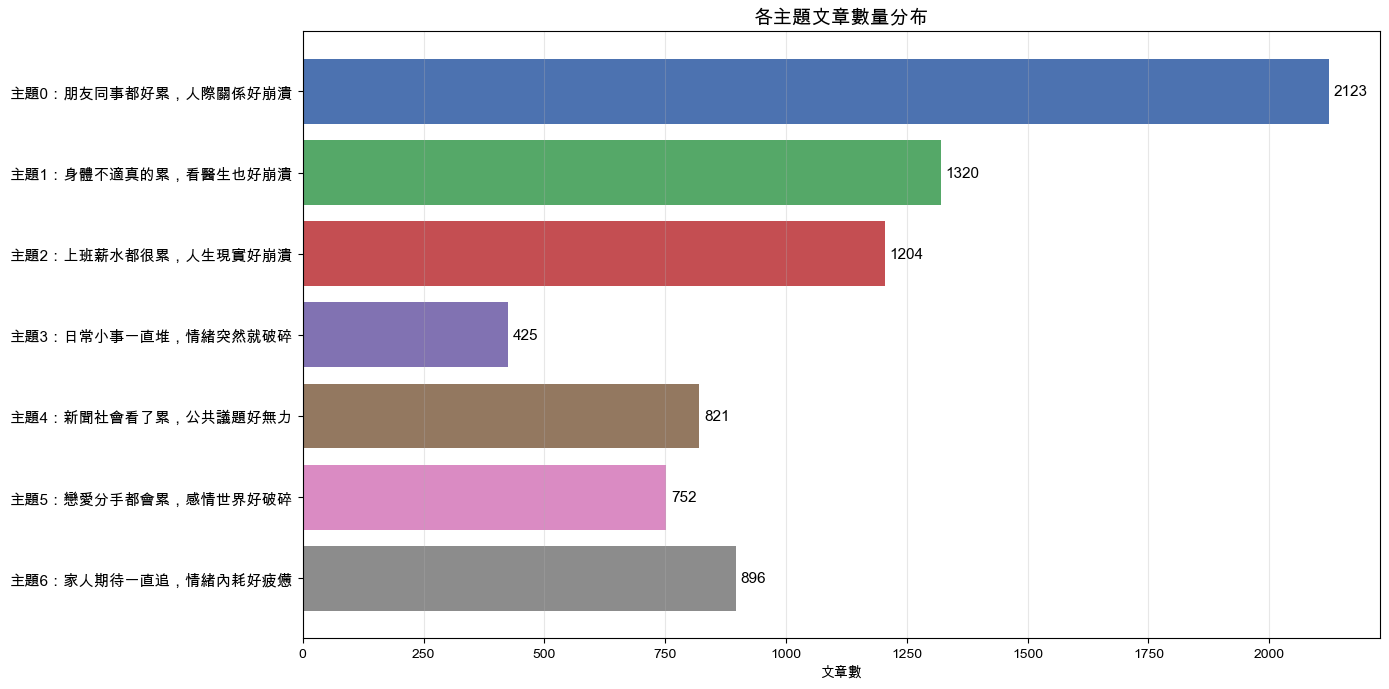

In [64]:
# 3-5b 視覺化：各主題文章數分布

y_labels = [f"主題{i}：{topic_labels.get(i, '')}" for i in range(best_k)]

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(range(best_k - 1, -1, -1), topic_counts.values, color=colors[:best_k])
ax.set_yticks(range(best_k - 1, -1, -1))
ax.set_yticklabels(y_labels, fontsize=11)
for bar, count in zip(bars, topic_counts.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            str(count), ha="left", va="center", fontsize=11)
ax.set_xlabel("文章數")
ax.set_title("各主題文章數量分布", fontsize=14)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [65]:
# 3-5c 標籤 × 主題 交叉表

cross_tab = pd.crosstab(
    df_analysis["tag"], 
    df_analysis["dominant_topic"],
    margins=True,
)

# 短版：只取逗號前面那句
cross_tab.columns = [
    f"主題{c}：{topic_labels.get(c, '').split('，')[0]}" if c != "All" else "合計"
    for c in cross_tab.columns
]

print("表 3-5c 標籤 × 主題 交叉表")
display(cross_tab)

表 3-5c 標籤 × 主題 交叉表


,主題0：朋友同事都好累,主題1：身體不適真的累,主題2：上班薪水都很累,主題3：日常小事一直堆,主題4：新聞社會看了累,主題5：戀愛分手都會累,主題6：家人期待一直追,合計
tag,,,,,,,,
問卦,0,0,0,0,2,1,0,3
問題,27,14,16,2,27,29,38,153
徵選,2,0,0,0,1,0,0,3
心得,0,0,1,0,0,0,0,1
心情,62,39,38,13,32,65,116,365
情報,0,0,0,0,1,0,0,1
新聞,1,5,3,4,66,40,4,123
活動,1,1,0,0,0,2,0,4
灑花,3,2,3,0,1,4,1,14


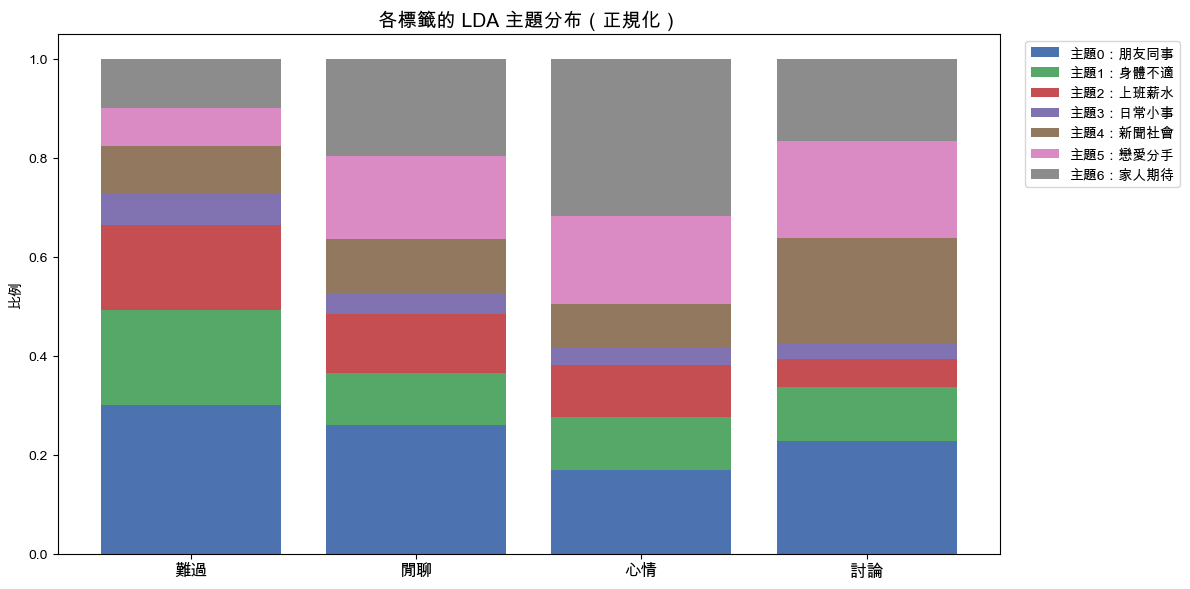

解讀：如果不同標籤的主題分布有明顯差異，代表 LDA 捕捉到了標籤背後的語義差異。


In [67]:
# 3-5d 視覺化：各標籤的主題分布（堆疊長條圖）

main_tags = ["難過", "閒聊", "心情", "討論"]
tag_topic_data = {}
for tag in main_tags:
    tag_df = df_analysis[df_analysis["tag"] == tag]
    if len(tag_df) == 0:
        continue
    dist = tag_df["dominant_topic"].value_counts().reindex(range(best_k), fill_value=0)
    tag_topic_data[tag] = (dist / dist.sum()).values

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(tag_topic_data))
width = 0.8
bottom = np.zeros(len(tag_topic_data))

for topic_id in range(best_k):
    values = [tag_topic_data[tag][topic_id] for tag in tag_topic_data]
    short_label = topic_labels.get(topic_id, "未命名")[:4]
    ax.bar(x, values, width, bottom=bottom,
           label=f"主題{topic_id}：{short_label}",
           color=colors[topic_id % len(colors)])
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(list(tag_topic_data.keys()), fontsize=12)
ax.set_ylabel("比例")
ax.set_title("各標籤的 LDA 主題分布（正規化）", fontsize=14)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

print("解讀：如果不同標籤的主題分布有明顯差異，代表 LDA 捕捉到了標籤背後的語義差異。")

## 3-6. pyLDAvis 互動式視覺化

pyLDAvis 是 LDA 最經典的視覺化工具，它把主題模型呈現為一張互動式的二維地圖：
- **左邊**：每個圓圈代表一個主題，圓圈大小 = 文章佔比，距離 = 主題相似度。
- **右邊**：選中某主題後，顯示該主題的關鍵詞與權重。

圓圈之間距離越遠，代表主題差異越大（分得越好）；圓圈重疊代表主題混淆。

In [68]:
# 3-6 pyLDAvis 視覺化

if pyldavis_available:
    print("準備 pyLDAvis 視覺化...")
    
    vis_data = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)
    pyLDAvis.enable_notebook()
    print("視覺化已準備完成，請在下方互動操作：")
    print("   - 點擊左邊的圓圈可以查看該主題的關鍵詞")
    print("   - 調整右上角的 λ 滑桿可以改變詞彙排序方式")
    display(vis_data)
else:
    print("pyLDAvis 未安裝，略過此段。")
    print("   請執行 !pip install pyLDAvis 後重跑此格。")

準備 pyLDAvis 視覺化...


/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=7034) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=7034) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=7034) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=7034) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: T

視覺化已準備完成，請在下方互動操作：
   - 點擊左邊的圓圈可以查看該主題的關鍵詞
   - 調整右上角的 λ 滑桿可以改變詞彙排序方式


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.065202  0.002273       1        1  19.051269
1     -0.135443 -0.032001       2        1  12.395150
2     -0.042231 -0.138587       3        1  12.992400
3     -0.102149  0.152970       4        1   5.654647
4      0.172145  0.020758       5        1  16.864237
5      0.115951  0.039334       6        1  14.687359
6      0.056927 -0.044747       7        1  18.354938, topic_info=    Term         Freq        Total Category  logprob  loglift
180   工作  1756.000000  1756.000000  Default  30.0000  30.0000
703   同事   967.000000   967.000000  Default  29.0000  29.0000
287   男友   684.000000   684.000000  Default  28.0000  28.0000
24    公司   919.000000   919.000000  Default  27.0000  27.0000
299   媽媽   673.000000   673.000000  Default  26.0000  26.0000
..   ...          ...          ...      ...      ...      ...
113   只能   202.246487   816.854336   Topic7  -5.6665   0.2993
395   不想   193.455218   770.630324   Topic7  -5.7109   0.3131
732   每天   185.051731   680.120435   Topic7  -5.7553   0.3936
921   以前   182.240629   691.378330   Topic7  -5.7707   0.3619
111   不好   174.230694   611.072478   Topic7  -5.8156   0.4404

[546 rows x 6 columns], token_table=      Topic      Freq Term
term                      
683       1  0.292749   一堆
683       2  0.171198   一堆
683       3  0.224270   一堆
683       4  0.123263   一堆
683       5  0.109567   一堆
...     ...       ...  ...
258       1  0.011098   鼻子
258       2  0.443915   鼻子
258       4  0.488307   鼻子
258       5  0.033294   鼻子
258       7  0.011098   鼻子

[1719 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7])

## 3-7. 各主題的代表文章

這裡會為每個主題挑出**最具代表性的文章**（主題機率最高的前 3 篇），可以回到原文脈絡去驗證主題的合理性。

In [69]:
# 3-7 各主題的代表文章（Top 3）

print("各主題最具代表性的文章（主題機率最高的前 3 篇）：\n")

for topic_id in range(best_k):
    top3_words = ", ".join([w for w, _ in topic_keywords[topic_id][:5]])
    print(f"{'='*70}")
    print(f"主題 {topic_id}：{top3_words}")
    print(f"{'='*70}")
    
    topic_df = df_analysis[df_analysis["dominant_topic"] == topic_id].copy()
    top_docs = topic_df.nlargest(3, "topic_prob")
    
    for rank, (_, row) in enumerate(top_docs.iterrows(), 1):
        title = row["artTitle"] if "artTitle" in row.index else row.get("clean_title", "")
        content_preview = str(row["clean_content"])[:200]
        print(f"\n  [{rank}] 機率: {row['topic_prob']:.3f} | 標籤: [{row['tag']}]")
        print(f"      標題: {title}")
        print(f"      內文: {content_preview}...")
    print()

各主題最具代表性的文章（主題機率最高的前 3 篇）：

主題 0：朋友, 結果, 是不是, 發現, 喜歡

  [1] 機率: 0.995 | 標籤: [難過]
      標題: Re:[難過]老高說得很殘酷
      內文: 關於程式鬼才 問我就對了 其實原 講的還並不算鬼才 真正的強者遠在你想像之上 分享以前的網路故事 很久以前，那還是我用 的時候有次我系統當機了，因為我是電腦白痴，我朋友給我介 紹了一個高手來幫我修電腦。 他看了一下電腦，問我有沒有 的安裝檔，我說沒有。 他想了一下，叫我把固定電話拿給他，我想修電腦要電話幹什麼，但人家是高手，我也 不好說什麼，就把電話拔下來給他了。 他把電話線空著的一頭接在電腦的一...

  [2] 機率: 0.993 | 標籤: [難過]
      標題: [難過]有人叫我不要開車了
      內文: 開車這幾年，事故率有點高， 年撞了 次 尤其是山路轉彎跟倒車入庫特別容易跟人擦撞到 有人跟我說再開慢一點 有人跟我說是空間感不好，無法掌握車子和周遭的距離 確實是這樣沒錯 我陸陸續續有搭配環景在練習 但每次只要太有自信覺得這次角度不錯可以一次過 結果就是撞 保持不自信的狀態比較安全 轉彎怕車頭撞到路緣水泥墩 怕撞到柱子 怕擦到牆壁 那就下車查看 只是 看起來路上 的人都已有掌握車子和周遭距離的能力...

  [3] 機率: 0.991 | 標籤: [難過]
      標題: [難過]以前的朋友當律師後見錢眼開
      內文: 事情是這樣的 我高中時期的好閨密叫 我們快要有 年沒聯絡了 只有過年過節偶爾傳傳貼圖 最近因為不小心騎車被汽車撞 （我直行被突然衝出來的車撞） 想說好久沒跟以前的姐妹見面吃飯 再加上剛好想請她幫忙估可以跟對方求償多少 我就在臉書跟她聯絡。 我： 好久不見！ ：嗨嗨 我：可以一起吃個飯嗎？我最近車禍了 ：天啊，妳人還好嗎？ 我：我還好，但想請妳幫我評估這樣可以求償多少 我：你們律師應該每天都在算比較...

主題 1：醫生, 結果, 上班, 啊啊啊, 晚上

  [1] 機率: 0.997 | 標籤: [難過]
      標題: [難過]我的狗狗…心痛到無法言喻
      內文: 現在非常的心痛，但為時已晚。 因為我家的狗狗也回不來了。 更諷刺的是，我在他走了之後第三天才發現有問題。 

## 3-8. GuidedLDA：種子詞引導主題

一般的 LDA 是完全無監督的，主題由資料自行決定。
**GuidedLDA** 允許我們為某些主題提供「種子詞」（seed words），引導模型往我們預期的方向發展。

這在本研究中特別有用，因為我們已經從 Part 1 的詞頻分析中觀察到幾個明顯的主題方向（感情、職場、家庭等），可以用種子詞幫助模型更清楚地分離這些主題。

In [71]:
# 3-8a GuidedLDA 種子詞設定與訓練
!pip install guidedlda
if guidedlda_available:
    from sklearn.feature_extraction.text import CountVectorizer as CV
    
    # 建立 CountVectorizer 語料（GuidedLDA 的輸入格式）
    guided_vec = CV(max_features=5000, min_df=5, max_df=0.7)
    guided_matrix = guided_vec.fit_transform(df_analysis["tokens_str"])
    guided_vocab = guided_vec.get_feature_names_out()
    word2id = {w: i for i, w in enumerate(guided_vocab)}
    
    # 定義種子詞（根據 Part 1 觀察到的主要方向）
    seed_topics = {
        0: ["分手", "失戀", "前任", "復合", "男友", "女友"],       # 感情分手
        1: ["工作", "上班", "同事", "主管", "離職", "老闆"],       # 職場壓力
        2: ["家人", "媽媽", "爸爸", "婆婆", "家庭"],              # 家庭關係
        3: ["朋友", "友情", "吵架", "交友"],                      # 人際關係
        4: ["身體", "生病", "醫院", "手術", "治療"],              # 健康問題
    }
    
    n_guided_topics = len(seed_topics)
    
    # 建立 seed_confidence 矩陣
    seed_confidence = np.zeros((n_guided_topics, len(guided_vocab)))
    for topic_id, seed_words in seed_topics.items():
        for word in seed_words:
            if word in word2id:
                seed_confidence[topic_id, word2id[word]] = 1.0
    
    print(f"GuidedLDA 設定：{n_guided_topics} 個引導主題")
    for tid, words in seed_topics.items():
        found = [w for w in words if w in word2id]
        print(f"  主題 {tid}: {found}")
    
    # 訓練
    print("\n訓練 GuidedLDA（約需 2-5 分鐘）...")
    guided_model = guidedlda.GuidedLDA(
        n_topics=n_guided_topics,
        n_iter=100,
        random_state=42,
        refresh=20,
    )
    guided_model.fit(guided_matrix.toarray(), seed_topics=seed_confidence, seed_confidence=0.15)
    
    print("GuidedLDA 訓練完成")
    
else:
    print("GuidedLDA 未安裝，略過此段。")
    print("   安裝方式：!pip install guidedlda")

/opt/anaconda3/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=7034) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 2.8 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... one
  DEPRECATION: Building 'guidedlda' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'guidedlda'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [172 lines of output]
      /opt/anaconda3/lib/python3.13/site-packages/setuptools/dist.py:447: SetuptoolsDeprecationWarning: Invalid dash-separated options
      !!
      
              ********************************************************************************
              Usage o

In [72]:
# 3-8b GuidedLDA 各主題關鍵詞

if guidedlda_available:
    print(f"GuidedLDA 各主題 Top 15 關鍵詞：\n")
    
    guided_topic_keywords = {}
    for topic_id in range(n_guided_topics):
        top_word_ids = guided_model.topic_word_[topic_id].argsort()[::-1][:15]
        top_words = [(guided_vocab[wid], guided_model.topic_word_[topic_id][wid]) 
                     for wid in top_word_ids]
        guided_topic_keywords[topic_id] = top_words
        
        seed_label = ", ".join(seed_topics[topic_id][:3])
        words_str = ", ".join([f"{w}({p:.4f})" for w, p in top_words])
        print(f"主題 {topic_id}（種子：{seed_label}）:")
        print(f"  {words_str}")
        print()
    
    # 視覺化
    fig, axes = plt.subplots(1, n_guided_topics, figsize=(5 * n_guided_topics, 5))
    if n_guided_topics == 1:
        axes = [axes]
    
    for topic_id in range(n_guided_topics):
        top10 = guided_topic_keywords[topic_id][:10]
        words = [w for w, _ in top10]
        weights = [p for _, p in top10]
        
        axes[topic_id].barh(range(9, -1, -1), weights, 
                            color=colors[topic_id % len(colors)])
        axes[topic_id].set_yticks(range(9, -1, -1))
        axes[topic_id].set_yticklabels(words)
        axes[topic_id].set_xlabel("詞彙權重")
        seed_label = ", ".join(seed_topics[topic_id][:2])
        axes[topic_id].set_title(f"主題{topic_id}（{seed_label}）", fontsize=11)
    
    plt.suptitle("GuidedLDA 各主題 Top 10 關鍵詞", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    print("解讀：和無引導的 LDA 比較，GuidedLDA 的主題是否更容易命名？")
    print("如果種子詞方向正確，主題應該更聚焦、更容易解釋。")
else:
    print("GuidedLDA 未安裝，略過此段。")

GuidedLDA 未安裝，略過此段。


## 3-9. LDA vs GuidedLDA 比較

如果 GuidedLDA 可用，這裡會把兩種方法的主題並排比較，觀察：
- 種子詞引導是否讓主題更聚焦。
- 是否有些主題在兩種方法中都一致出現（代表資料本身就有這個結構）。

In [73]:
# 3-9 LDA vs GuidedLDA 主題摘要比較

print("=" * 70)
print("主題模型比較摘要")
print("=" * 70)

print(f"\n【LDA（無引導，k={best_k}）】")
for topic_id in range(best_k):
    top5 = ", ".join([w for w, _ in topic_keywords[topic_id][:5]])
    count = (df_analysis["dominant_topic"] == topic_id).sum()
    print(f"  主題 {topic_id}: {top5}（{count} 篇）")

if guidedlda_available:
    print(f"\n【GuidedLDA（有引導，k={n_guided_topics}）】")
    for topic_id in range(n_guided_topics):
        top5 = ", ".join([w for w, _ in guided_topic_keywords[topic_id][:5]])
        seed_hint = ", ".join(seed_topics[topic_id][:3])
        print(f"  主題 {topic_id}（種子：{seed_hint}）: {top5}")
else:
    print("\n【GuidedLDA 未安裝，無法比較】")

print("\n" + "=" * 70)

主題模型比較摘要

【LDA（無引導，k=7）】
  主題 0: 朋友, 結果, 是不是, 發現, 喜歡（2123 篇）
  主題 1: 醫生, 結果, 上班, 啊啊啊, 晚上（1320 篇）
  主題 2: 工作, 公司, 同事, 上班, 薪水（1204 篇）
  主題 3: 老師, 可是, 時間, 回家, 起來（425 篇）
  主題 4: 台灣, 新聞, 社會, 這些, 不要（821 篇）
  主題 5: 男友, 女生, 一起, 朋友, 結婚（752 篇）
  主題 6: 媽媽, 小孩, 工作, 不要, 爸爸（896 篇）

【GuidedLDA 未安裝，無法比較】



## 3-10. 輸出主題分析結果

把主題標記結果存成 CSV，方便後續分析或撰寫報告。

In [74]:
# 3-10 輸出主題分析結果

output_cols = [
    "artTitle", "tag", "artDate", "artUrl",
    "clean_content", "dominant_topic", "topic_prob",
]
available_cols = [c for c in output_cols if c in df_analysis.columns]

df_analysis[available_cols].to_csv(
    results_dir / "topic_analysis_results.csv",
    index=False,
    encoding="utf-8-sig",
)

# 輸出主題關鍵詞表
topic_summary_rows = []
for topic_id in range(best_k):
    for rank, (word, weight) in enumerate(topic_keywords[topic_id][:15], 1):
        topic_summary_rows.append({
            "topic_id": topic_id,
            "rank": rank,
            "word": word,
            "weight": round(weight, 4),
        })

topic_summary_df = pd.DataFrame(topic_summary_rows)
topic_summary_df.to_csv(
    results_dir / "lda_topic_keywords.csv",
    index=False,
    encoding="utf-8-sig",
)

print(f"已輸出：")
print(f"   {results_dir / 'topic_analysis_results.csv'}")
print(f"   {results_dir / 'lda_topic_keywords.csv'}")

已輸出：
   /Users/sylvia/Documents/Sylvia/社群媒體分析/第二次讀書會報告/results/topic_analysis_results.csv
   /Users/sylvia/Documents/Sylvia/社群媒體分析/第二次讀書會報告/results/lda_topic_keywords.csv


## Part 3 小結

Part 3 使用主題模型從「難過」貼文中發掘隱含主題：

1. **gensim LDA**：無監督地發現語料中的潛在主題。
2. **Perplexity / C_NPMI**：用量化指標找到最佳主題數 k，避免主觀猜測。
3. **pyLDAvis**：互動式視覺化主題間的關係與區分度。

主要發現：
- 透過 Coherence 指標，可以客觀地選出最佳主題數。
- LDA 發現的主題可以和 Part 1 的高頻詞、Part 2 的分類特徵互相印證。